# Kalman Filter

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime, timedelta
import seaborn as sns

In [2]:
def plot_timeseries(dfs, value_column, 
                   plot_type='line', 
                   sample_rate=None, 
                   date_range=None,
                   figsize=(15, 8),
                   highlight_filled=False,
                   filled_df=None,
                   title=None,
                   labels=None):
    """
    Plots time series data from a list of DataFrames with DateTimeIndex.
    Each DataFrame is plotted as a separate line with the same style but different colors_line.

    Args:
        dfs (list of pd.DataFrame): List of DataFrames with time series data (must have DateTimeIndex)
        value_column (str): Name of the value column
        plot_type (str): 'line', 'scatter', 'both', or 'resampled'
        sample_rate (int): If provided, sample to at most this many points per DataFrame
        date_range (tuple): (start_date, end_date) to filter the data
        figsize (tuple): Figure size (width, height)
        highlight_filled (bool): Whether to highlight ARIMA-filled values (only works with single DF)
        filled_df (pd.DataFrame): DataFrame with filled values (if highlighting)
        title (str): Custom plot title
        labels (list): Custom labels for each DataFrame (if None, uses DF1, DF2, etc.)

    Returns:
        matplotlib.figure.Figure

    Examples:
        # Basic usage with multiple DataFrames
        fig = plot_timeseries([df1, df2, df3], 'Value')

        # With custom labels and plot type
        fig = plot_timeseries([original_df, resampled_df], 'Diff.', 
                             labels=['Original', 'Resampled'],
                             plot_type='line')

        # Comparing different preprocessing results
        fig = plot_timeseries([raw_data, hourly_resampled, interpolated], 'Value',
                             labels=['Raw', 'Hourly', 'Interpolated'],
                             title='Data Preprocessing Comparison')
    """

    # Input validation
    if not isinstance(dfs, list):
        raise ValueError("First parameter must be a list of DataFrames")

    if len(dfs) == 0:
        raise ValueError("List of DataFrames cannot be empty")

    # Check that all DataFrames have DateTimeIndex
    for i, df in enumerate(dfs):
        if not isinstance(df.index, pd.DatetimeIndex):
            raise ValueError(f"DataFrame {i} must have a DateTimeIndex")
        if value_column not in df.columns:
            raise ValueError(f"Column '{value_column}' not found in DataFrame {i}")

    # Default labels if not provided
    if labels is None:
        labels = [f"DF{i+1}" for i in range(len(dfs))]
    elif len(labels) != len(dfs):
        raise ValueError("Number of labels must match number of DataFrames")

    # Color palette for different lines - use tab10 colormap for up to 10 distinct colors
    if len(dfs) < 5:
        colors_line = plt.cm.tab10([0, 3, 6, 9])
        colors_scatter = plt.cm.tab10([1, 4, 7, 8])
    else:
        # For more than 10 DataFrames, use a continuous colormap
        colors_line = plt.cm.viridis(np.linspace(0, 1, len(dfs)))

    # Prepare DataFrames
    dfs_plot = []
    total_points = 0

    for i, df in enumerate(dfs):
        # Work on a copy
        df_plot = df.copy().sort_index()

        # Filter by date range
        if date_range:
            start_date, end_date = date_range
            df_plot = df_plot.loc[start_date:end_date]

        # Downsample if requested
        if sample_rate and len(df_plot) > sample_rate:
            step = max(1, len(df_plot)//sample_rate)
            df_plot = df_plot.iloc[::step]

        dfs_plot.append(df_plot)
        total_points += len(df_plot)
        print(f"DataFrame {i+1} ({labels[i]}): {len(df_plot)} points")

    if date_range:
        print(f"Filtered to date range: {total_points} total points")

    # Create plot
    fig, ax = plt.subplots(figsize=figsize)

    if title is None:
        title = f"Time Series Plot - {value_column} ({total_points:,} total points)"

    # Plot each DataFrame
    for i, (df_plot, label, color_line, color_scatter) in enumerate(zip(dfs_plot, labels, colors_line, colors_scatter)):
        if len(df_plot) == 0:
            continue

        # Plot types - all DataFrames use same style but different colors_line
        if plot_type == 'line':
            ax.plot(df_plot.index, df_plot[value_column],
                    linewidth=1, alpha=1, color=color_line, label=label)

        elif plot_type == 'scatter':
            ax.scatter(df_plot.index, df_plot[value_column],
                       s=1, alpha=0.6, color=color_scatter, label=label)

        elif plot_type == 'both':
            ax.plot(df_plot.index, df_plot[value_column],
                    linewidth=0.8, alpha=0.8, color=color_line, label=f'{label} (Line)')
            ax.scatter(df_plot.index, df_plot[value_column],
                       s=1, alpha=0.6, color=color_scatter, label=f'{label} (Points)')

        elif plot_type == 'resampled':
            df_resampled = df_plot[value_column].resample('h').mean()
            ax.plot(df_resampled.index, df_resampled,
                    linewidth=1, color=color_line, label=f'{label} (Hourly Avg)')
            print(f"DataFrame {i+1} resampled to hourly averages: {len(df_resampled)} points")

    # Highlight filled values (only works with single DataFrame for backwards compatibility)
    if highlight_filled and filled_df is not None and len(dfs) == 1:
        if not isinstance(filled_df.index, pd.DatetimeIndex):
            raise ValueError("filled_df must also have a DateTimeIndex")
        filled_copy = filled_df.copy().sort_index()

        # Find timestamps in filled_df but missing in original df
        new_times = filled_copy.index.difference(dfs[0].index)

        if not new_times.empty:
            filled_only = filled_copy.loc[new_times]
            if date_range:
                start_date, end_date = date_range
                filled_only = filled_only.loc[start_date:end_date]

            if not filled_only.empty:
                ax.scatter(filled_only.index, filled_only[value_column],
                           s=3, color='red', alpha=0.8,
                           label='ARIMA Filled', zorder=5)
                print(f"Highlighted {len(filled_only)} filled values")

    # Labels and formatting
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel(value_column, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # Enhanced stats box for multiple DataFrames
    stats_lines = []
    for i, (df_plot, label) in enumerate(zip(dfs_plot, labels)):
        if len(df_plot) > 0:
            stats_lines.append(f"{label}:")
            stats_lines.append(f"  Min: {df_plot[value_column].min():.2f}")
            stats_lines.append(f"  Max: {df_plot[value_column].max():.2f}")
            stats_lines.append(f"  Mean: {df_plot[value_column].mean():.2f}")
            stats_lines.append(f"  Std: {df_plot[value_column].std():.2f}")
            if i < len(dfs_plot) - 1:  # Add separator except for last
                stats_lines.append("---")

    stats_text = "\n".join(stats_lines)

    # Adjust stats box font size based on number of DataFrames
    font_size = max(8, min(10, 10 - len(dfs) // 3))

    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle='round',
            facecolor='wheat', alpha=0.8), fontsize=font_size)

    plt.tight_layout()
    plt.show()
    #return fig

# Convenience function for common use cases
def compare_preprocessing_results(original_df, resampled_df, interpolated_df=None, 
                                 value_column='Value', **kwargs):
    """
    Convenience function to compare original, resampled, and optionally interpolated data.

    Args:
        original_df: Original water meter data
        resampled_df: Resampled hourly data  
        interpolated_df: Optional interpolated data
        value_column: Column to plot
        **kwargs: Additional arguments passed to plot_timeseries
    """
    dfs = [original_df, resampled_df]
    labels = ['Original', 'Resampled']

    if interpolated_df is not None:
        dfs.append(interpolated_df)
        labels.append('Interpolated')

    return plot_timeseries(dfs, value_column, labels=labels, 
                          title=f'Data Preprocessing Comparison - {value_column}',
                          **kwargs)


In [3]:
graph2 = pd.read_csv('data/VAR_41494_55419-odecty.csv', sep=";")[['VAR_ID', 'Time of reading', 'Value', 'Diff.']]
def index_dataset(df, time_column):
    df[time_column] = pd.to_datetime(df[time_column])
    df.sort_values(time_column, inplace=True)
    df.set_index(time_column, inplace=True)
        
index_dataset(graph2, "Time of reading")
graph2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17267 entries, 2024-08-29 00:14:56 to 2025-08-29 17:06:45
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   VAR_ID  17267 non-null  int64  
 1   Value   17267 non-null  float64
 2   Diff.   17266 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 539.6 KB


In [4]:
graph2["Diff."].isnull().values.sum()

1

In [5]:
graph2[graph2.isna().any(axis=1)]

,VAR_ID,Value,Diff.
Time of reading,,,
2024-08-29 00:14:56,55419,789.73,NaN


In [6]:
graph2 = graph2.dropna()
graph2.head()

,VAR_ID,Value,Diff.
Time of reading,,,
2024-08-29 00:44:56,55419,789.73,0.0
2024-08-29 01:14:56,55419,789.73,0.0
2024-08-29 01:44:56,55419,789.73,0.0
2024-08-29 02:14:56,55419,789.73,0.0
2024-08-29 02:44:56,55419,789.73,0.0


In [7]:
graph2_resampled = graph2.resample('30T').asfreq()
graph2_resampled["Diff."].isnull().values.sum()

C:\Users\Ondřej Černý\AppData\Local\Temp\ipykernel_4384\148022758.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  graph2_resampled = graph2.resample('30T').asfreq()


17554

In [8]:
class KalmanFilterRandomWalk:
    def __init__(self, Q=1e-5, R=1e-5, A=np.array([[1]])):
        # State transition matrix
        self.A = A
        # Observation matrix
        self.H = np.array([[1]])
        # Process noise covariance
        self.Q = np.array([[Q]])
        # Measurement noise covariance
        self.R = np.array([[R]])
        # Initial state estimate
        self.x_hat = None
        # Initial covariance estimate
        self.P = None
        
    def initialize(self, initial_state=0, initial_covariance=1):
        self.x_hat = np.array([[initial_state]])
        self.P = np.array([[initial_covariance]])
        
    def predict(self):
        # Predict the next state
        self.x_hat = self.A @ self.x_hat
        self.P = self.A @ self.P @ self.A.T + self.Q
        
    def update(self, measurement):
        # Innovation
        y_tilde = measurement - (self.H @ self.x_hat)
        # Innovation covariance
        S = self.H @ self.P @ self.H.T + self.R
        # Kalman gain
        K = self.P @ self.H.T @ np.linalg.inv(S)
        # Update state estimate
        self.x_hat = self.x_hat + K @ y_tilde
        # Update covariance estimate
        self.P = (np.eye(self.P.shape[0]) - K @ self.H) @ self.P
        return y_tilde, S  # Return innovation and its covariance

def run_kalman_filter_on_diff(df, Q=1e-5, R=1e-5, A=np.array([[1]])):
    """
    Runs Kalman filter on Diff. values of DataFrame df.
    Assumes df.index is the time of reading and df['Diff'] contains Diff. values.
    
    Returns:
    - df_results: original df with added columns for state estimate, innovation, and innovation magnitude
    """
    kf = KalmanFilterRandomWalk(Q=Q, R=R, A=A)
    kf.initialize(initial_state=0, initial_covariance=1)
    
    state_estimates = []
    innovation_vals = []
    innovation_magnitudes = []
    
    for diff_val in df['Diff.']:
        kf.predict()
        innovation, S = kf.update(np.array([[diff_val]]))
        state_estimates.append(kf.x_hat.item())
        innovation_vals.append(innovation.item())
        innovation_magnitudes.append(np.sqrt(innovation.T @ np.linalg.inv(S) @ innovation).item())
    
    df_results = df.copy()
    df_results['Diff.'] = state_estimates
    df_results['Innovation'] = innovation_vals
    df_results['Innovation_Magnitude'] = innovation_magnitudes
    
    return df_results

# Example usage:
# df is your DataFrame with DateTime index and 'Diff' column
graph2_last_week = graph2[-48*7:]
df_filtered = run_kalman_filter_on_diff(graph2_last_week, Q=0.00005, R=0.0009)
# You can then analyze df_filtered['Innovation_Magnitude'] for anomalies.


In [9]:
df_filtered.head()

,VAR_ID,Value,Diff.,Innovation,Innovation_Magnitude
Time of reading,,,,,
2025-08-22 17:36:55,55419,851.09,0.000000,0.000000,0.000000
2025-08-22 18:06:55,55419,851.09,0.000000,0.000000,0.000000
2025-08-22 18:36:55,55419,851.10,0.003626,0.010000,0.266126
2025-08-22 19:06:55,55419,851.10,0.002557,-0.003626,0.101493
2025-08-22 19:36:55,55419,851.10,0.001893,-0.002557,0.073340


DataFrame 1 (DF1): 336 points
DataFrame 2 (DF2): 336 points


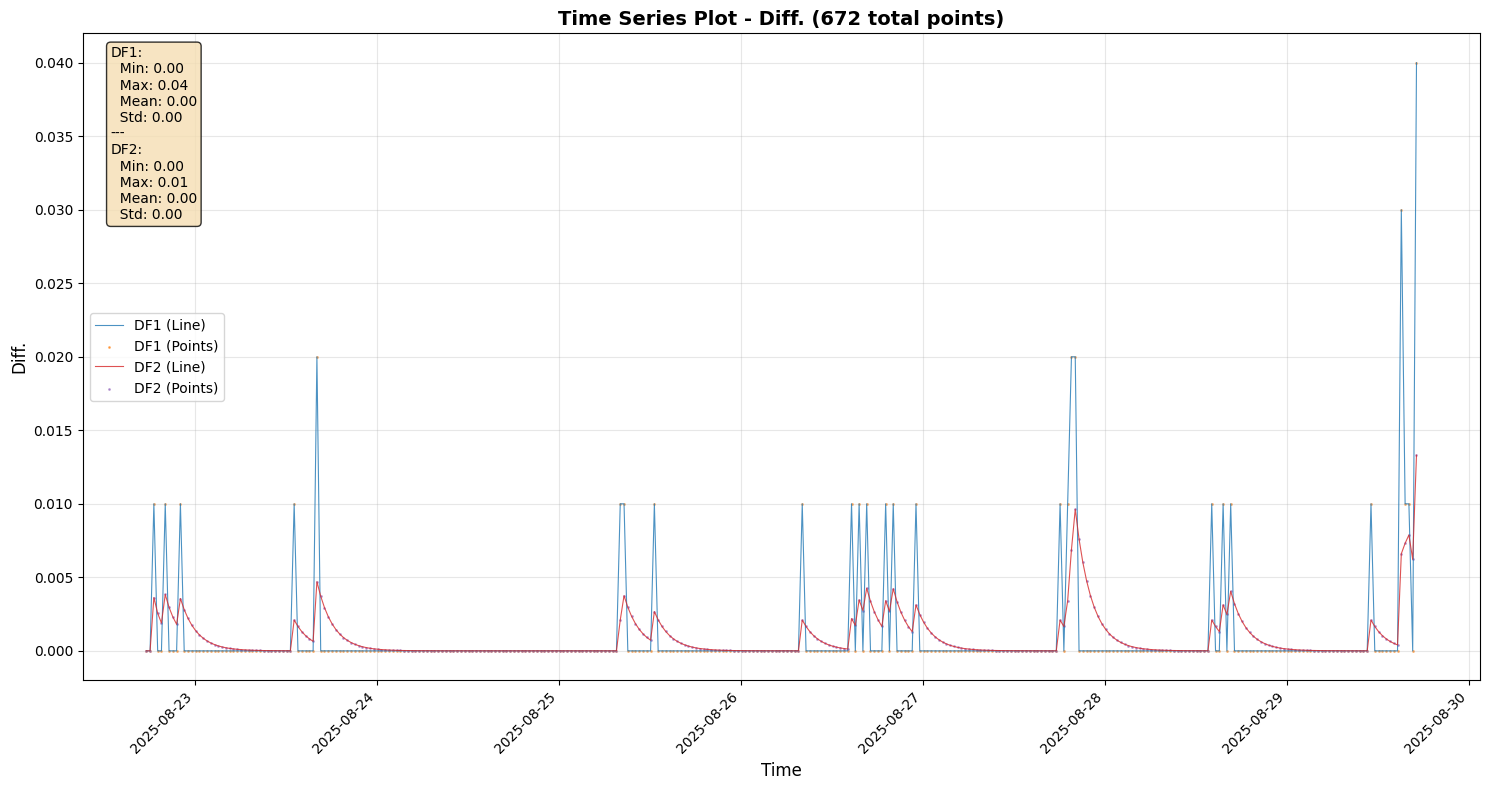

In [10]:
plot_timeseries([graph2_last_week, df_filtered], value_column="Diff.", plot_type="both")

## Seasonal KF

Structural models, statsmodels. Sarimax

In [11]:
def plot_timeseries(dfs, value_column, 
                   plot_type='line', 
                   sample_rate=None, 
                   date_range=None,
                   figsize=(15, 8),
                   highlight_filled=False,
                   filled_df=None,
                   title=None,
                   labels=None):
    """
    Plots time series data from a list of DataFrames with a 'timestamp' column.
    Each DataFrame is plotted as a separate line with the same style but different colors.

    Args:
        dfs (list of pd.DataFrame): List of DataFrames with time series data (must have 'timestamp' column)
        value_column (str): Name of the value column
        plot_type (str): 'line', 'scatter', 'both', or 'resampled'
        sample_rate (int): If provided, sample to at most this many points per DataFrame
        date_range (tuple): (start_date, end_date) to filter the data
        figsize (tuple): Figure size (width, height)
        highlight_filled (bool): Whether to highlight ARIMA-filled values (only works with single DF)
        filled_df (pd.DataFrame): DataFrame with filled values (if highlighting)
        title (str): Custom plot title
        labels (list): Custom labels for each DataFrame (if None, uses DF1, DF2, etc.)

    Returns:
        matplotlib.figure.Figure

    Examples:
        # Basic usage with multiple DataFrames
        fig = plot_timeseries([df1, df2, df3], 'Value')

        # With custom labels and plot type
        fig = plot_timeseries([original_df, resampled_df], 'Diff.', 
                             labels=['Original', 'Resampled'],
                             plot_type='line')

        # Comparing different preprocessing results
        fig = plot_timeseries([raw_data, hourly_resampled, interpolated], 'Value',
                             labels=['Raw', 'Hourly', 'Interpolated'],
                             title='Data Preprocessing Comparison')
    """

    # Input validation
    if not isinstance(dfs, list):
        raise ValueError("First parameter must be a list of DataFrames")

    if len(dfs) == 0:
        raise ValueError("List of DataFrames cannot be empty")

    # Check that all DataFrames have 'timestamp' column
    for i, df in enumerate(dfs):
        if 'timestamp' not in df.columns:
            raise ValueError(f"DataFrame {i} must have a 'timestamp' column")
        if value_column not in df.columns:
            raise ValueError(f"Column '{value_column}' not found in DataFrame {i}")

    # Default labels if not provided
    if labels is None:
        labels = [f"DF{i+1}" for i in range(len(dfs))]
    elif len(labels) != len(dfs):
        raise ValueError("Number of labels must match number of DataFrames")

    # Color palette for different lines - use tab10 colormap for up to 10 distinct colors
    if len(dfs) < 5:
        colors_line = plt.cm.tab10([0, 3, 6, 9])
        colors_scatter = plt.cm.tab10([1, 4, 7, 8])
    else:
        # For more than 10 DataFrames, use a continuous colormap
        colors_line = plt.cm.viridis(np.linspace(0, 1, len(dfs)))
        colors_scatter = colors_line  # Use same colors for scatter when many DFs

    # Prepare DataFrames
    dfs_plot = []
    total_points = 0

    for i, df in enumerate(dfs):
        # Work on a copy
        df_plot = df.copy()
        
        # Ensure timestamp column is datetime
        df_plot['timestamp'] = pd.to_datetime(df_plot['timestamp'])

        # Filter by date range
        if date_range:
            start_date, end_date = date_range
            df_plot = df_plot[(df_plot['timestamp'] >= start_date) & 
                             (df_plot['timestamp'] <= end_date)]

        # Downsample if requested
        if sample_rate and len(df_plot) > sample_rate:
            step = max(1, len(df_plot)//sample_rate)
            df_plot = df_plot.iloc[::step]

        dfs_plot.append(df_plot)
        total_points += len(df_plot)
        print(f"DataFrame {i+1} ({labels[i]}): {len(df_plot)} points")

    if date_range:
        print(f"Filtered to date range: {total_points} total points")

    # Create plot
    fig, ax = plt.subplots(figsize=figsize)

    if title is None:
        title = f"Time Series Plot - {value_column} ({total_points:,} total points)"

    # Plot each DataFrame
    for i, (df_plot, label) in enumerate(zip(dfs_plot, labels)):
        if len(df_plot) == 0:
            continue

        # Get appropriate colors
        color_line = colors_line[i]
        color_scatter = colors_scatter[i] if i < len(colors_scatter) else color_line

        # Plot types - all DataFrames use same style but different colors
        if plot_type == 'line':
            ax.plot(df_plot['timestamp'], df_plot[value_column],
                    linewidth=1, alpha=1, color=color_line, label=label)

        elif plot_type == 'scatter':
            ax.scatter(df_plot['timestamp'], df_plot[value_column],
                       s=1, alpha=0.6, color=color_scatter, label=label)

        elif plot_type == 'both':
            ax.plot(df_plot['timestamp'], df_plot[value_column],
                    linewidth=0.8, alpha=0.8, color=color_line, label=f'{label} (Line)')
            ax.scatter(df_plot['timestamp'], df_plot[value_column],
                       s=1, alpha=0.6, color=color_scatter, label=f'{label} (Points)')

        elif plot_type == 'resampled':
            # For resampling, temporarily set timestamp as index
            df_temp = df_plot.set_index('timestamp')
            df_resampled = df_temp[value_column].resample('h').mean()
            ax.plot(df_resampled.index, df_resampled,
                    linewidth=1, color=color_line, label=f'{label} (Hourly Avg)')
            print(f"DataFrame {i+1} resampled to hourly averages: {len(df_resampled)} points")

    # Highlight filled values (only works with single DataFrame for backwards compatibility)
    if highlight_filled and filled_df is not None and len(dfs) == 1:
        if 'timestamp' not in filled_df.columns:
            raise ValueError("filled_df must also have a 'timestamp' column")
        
        filled_copy = filled_df.copy()
        filled_copy['timestamp'] = pd.to_datetime(filled_copy['timestamp'])
        filled_copy = filled_copy.sort_values('timestamp')

        # Find timestamps in filled_df but missing in original df
        original_timestamps = set(dfs[0]['timestamp'])
        filled_timestamps = set(filled_copy['timestamp'])
        new_times = filled_timestamps - original_timestamps

        if new_times:
            filled_only = filled_copy[filled_copy['timestamp'].isin(new_times)]
            
            if date_range:
                start_date, end_date = date_range
                filled_only = filled_only[(filled_only['timestamp'] >= start_date) & 
                                         (filled_only['timestamp'] <= end_date)]

            if not filled_only.empty:
                ax.scatter(filled_only['timestamp'], filled_only[value_column],
                           s=3, color='red', alpha=0.8,
                           label='ARIMA Filled', zorder=5)
                print(f"Highlighted {len(filled_only)} filled values")

    # Labels and formatting
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel(value_column, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # Enhanced stats box for multiple DataFrames
    stats_lines = []
    for i, (df_plot, label) in enumerate(zip(dfs_plot, labels)):
        if len(df_plot) > 0:
            stats_lines.append(f"{label}:")
            stats_lines.append(f"  Min: {df_plot[value_column].min():.2f}")
            stats_lines.append(f"  Max: {df_plot[value_column].max():.2f}")
            stats_lines.append(f"  Mean: {df_plot[value_column].mean():.2f}")
            stats_lines.append(f"  Std: {df_plot[value_column].std():.2f}")
            if i < len(dfs_plot) - 1:  # Add separator except for last
                stats_lines.append("---")

    stats_text = "\n".join(stats_lines)

    # Adjust stats box font size based on number of DataFrames
    font_size = max(8, min(10, 10 - len(dfs) // 3))

    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle='round',
            facecolor='wheat', alpha=0.8), fontsize=font_size)

    plt.tight_layout()
    plt.show()
    #return fig


# Convenience function for common use cases
def compare_preprocessing_results(original_df, resampled_df, interpolated_df=None, 
                                 value_column='Value', **kwargs):
    """
    Convenience function to compare original, resampled, and optionally interpolated data.

    Args:
        original_df: Original water meter data
        resampled_df: Resampled hourly data  
        interpolated_df: Optional interpolated data
        value_column: Column to plot
        **kwargs: Additional arguments passed to plot_timeseries
    """
    dfs = [original_df, resampled_df]
    labels = ['Original', 'Resampled']

    if interpolated_df is not None:
        dfs.append(interpolated_df)
        labels.append('Interpolated')

    return plot_timeseries(dfs, value_column, labels=labels, 
                          title=f'Data Preprocessing Comparison - {value_column}',
                          **kwargs)


In [12]:
graph2.head()

,VAR_ID,Value,Diff.
Time of reading,,,
2024-08-29 00:44:56,55419,789.73,0.0
2024-08-29 01:14:56,55419,789.73,0.0
2024-08-29 01:44:56,55419,789.73,0.0
2024-08-29 02:14:56,55419,789.73,0.0
2024-08-29 02:44:56,55419,789.73,0.0


In [13]:
filled_df = pd.read_csv("../filled_data_complete.csv")
filled_df.rename(columns={"Diff." : "Diff"}, inplace=True)
filled_df_last_week = filled_df.iloc[-48*7:]
filled_df_last_month = filled_df.iloc[-5*48*7:-48*7] # actually last 4 weeks before the last week

In [14]:
df2 = pd.read_csv('data/VAR_97467_124449-odecty.csv', sep=";")[['VAR_ID', 'Time of reading', 'Value', 'Diff.']]
df2.rename(columns={'VAR_ID':'id', 'Time of reading':'timestamp', 'Value':'hodnota', 'Diff.':'Diff'}, inplace=True)
# Convert 'timestamp' to datetime (if needed)
df2['timestamp'] = pd.to_datetime(df2['timestamp'], errors='coerce')

# Sort by timestamp
df2 = df2.sort_values(by='timestamp')

# Reset index (optional, for a clean DataFrame)
df2 = df2.reset_index(drop=True)
df2=df2[2*30*48:]

display(df2.info())
display(df2.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13538 entries, 2880 to 16417
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   id         13538 non-null  int64         
 1   timestamp  13538 non-null  datetime64[ns]
 2   hodnota    13538 non-null  float64       
 3   Diff       13538 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 423.2 KB


None

,id,timestamp,hodnota,Diff
2880,124449,2024-11-13 22:11:38,241.185,0.0
2881,124449,2024-11-13 22:41:40,241.185,0.0
2882,124449,2024-11-13 23:11:41,241.185,0.0
2883,124449,2024-11-13 23:41:43,241.185,0.0
2884,124449,2024-11-14 00:11:44,241.185,0.0


In [15]:
test_df_last_4_weeks = df2.iloc[-4*7*48:]
test_df_8_to_4_weeks_ago = df2.iloc[(-8*7*48)+10:-4*7*48]
display(test_df_8_to_4_weeks_ago.tail())
display(test_df_last_4_weeks.head())
print(test_df_last_4_weeks.shape)
print(test_df_8_to_4_weeks_ago.shape)

,id,timestamp,hodnota,Diff
15069,124449,2025-07-31 21:02:12,355.845,0.0
15070,124449,2025-07-31 21:32:15,355.845,0.0
15071,124449,2025-07-31 22:02:17,355.845,0.0
15072,124449,2025-07-31 22:32:19,355.845,0.0
15073,124449,2025-07-31 23:02:22,355.845,0.0


,id,timestamp,hodnota,Diff
15074,124449,2025-07-31 23:32:24,355.845,0.0
15075,124449,2025-08-01 00:02:27,355.845,0.0
15076,124449,2025-08-01 00:32:29,355.845,0.0
15077,124449,2025-08-01 01:02:31,355.845,0.0
15078,124449,2025-08-01 01:32:33,355.845,0.0


(1344, 4)
(1334, 4)


DataFrame 1 (DF1): 13538 points


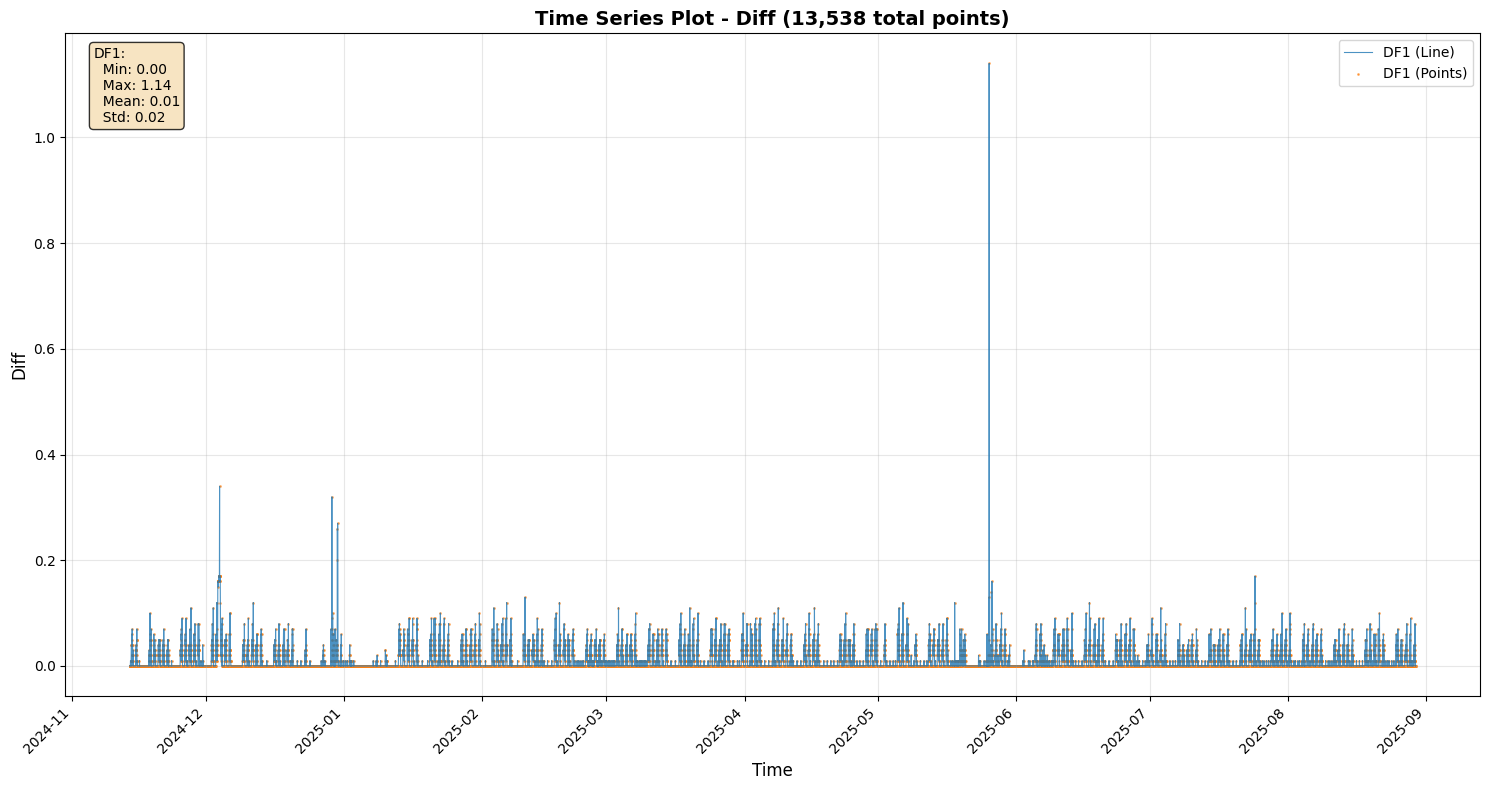

In [16]:
plot_timeseries([df2], 'Diff', plot_type="both")

In [17]:
from kf_wrls_estimator import KalmanFilterWRLSEstimator

# First run (no previous data)")
estimator = KalmanFilterWRLSEstimator(lambda_forget=0.9999)
n_harmonics=3

A, Q, R, metadata = estimator.estimate_from_dataframe(
    df2,
    expected_interval_seconds=30*60,
    n_harmonics=n_harmonics,
    tolerance_percent=10.0,
    verbose=True
)
estimator.save_matrices('sensor_test_df')


✓ Data Processing Summary:
  Time span: 6930.9 hours
  Expected readings (based on 1800s interval): 13862
  Expected pairs: 13861
  Valid pairs found: 13246
  Data validity: 95.6%


Starting WRLS estimation...
  State dimension: 7
  Forgetting factor λ = 0.9999

  Processed 100/13246 updates... Max |eigval(A)| = 1.0000
  Processed 200/13246 updates... Max |eigval(A)| = 1.0000
  Processed 300/13246 updates... Max |eigval(A)| = 1.0000
  Processed 400/13246 updates... Max |eigval(A)| = 1.0000
  Processed 500/13246 updates... Max |eigval(A)| = 1.0000
  Processed 600/13246 updates... Max |eigval(A)| = 1.0000
  Processed 700/13246 updates... Max |eigval(A)| = 1.0000
  Processed 800/13246 updates... Max |eigval(A)| = 1.0000
  Processed 900/13246 updates... Max |eigval(A)| = 1.0000
  Processed 1000/13246 updates... Max |eigval(A)| = 1.0000
  Processed 1100/13246 updates... Max |eigval(A)| = 1.0000
  Processed 1200/13246 updates... Max |eigval(A)| = 1.0000
  Processed 1300/13246 updates... Max 

In [18]:
eigvals = np.linalg.eigvals(A)
print("Final eigenvalues of A:", eigvals)
if np.any(np.abs(eigvals) > (1 + 1e-6)):
    print("WARNING: At least one eigenvalue of A is >= 1. Filtering may be unstable.")

Final eigenvalues of A: [0.46888894+0.j         0.92367615+0.38317383j 0.92367615-0.38317383j
 0.96583408+0.25916088j 0.96583408-0.25916088j 0.99142167+0.13070164j
 0.99142167-0.13070164j]


In [ ]:
from kf import WaterMeterKalmanFilter

#R = np.eye(2*n_harmonics + 1) * 0.0005
kf = WaterMeterKalmanFilter(A, Q, R, n_harmonics=n_harmonics, seasonal_period=24.0)

df_filtered = kf.filter_dataframe(df2, return_diagnostics=True)

[[4.67998255e-05 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 4.67998255e-07 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 4.67998255e-07 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 4.67998255e-07
  0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  4.67998255e-07 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 4.67998255e-07 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 4.67998255e-07]]



Kalman Filter Performance Metrics

Data Summary:
----------------------------------------------------------------------
  n_nonzero_measurements                       : 4063
  n_total_measurements                         : 13538
  nonzero_percentage                           : 30.011819
  n_anomalies_detected                         : 222

Prediction Accuracy (All Data):
----------------------------------------------------------------------
  MAE_prediction                               : 6.745178e-03
  RMSE_prediction                              : 0.019216
  ME_prediction                                : 5.235044e-03
  MedAE_prediction                             : 2.635326e-06
  MAPE_prediction                              : 3.763734e+08
  NRMSE_prediction                             : 0.888248
  R2_prediction                                : 0.211016

Prediction Accuracy (Non-Zero Only):
----------------------------------------------------------------------
  MAE_prediction_nonzer

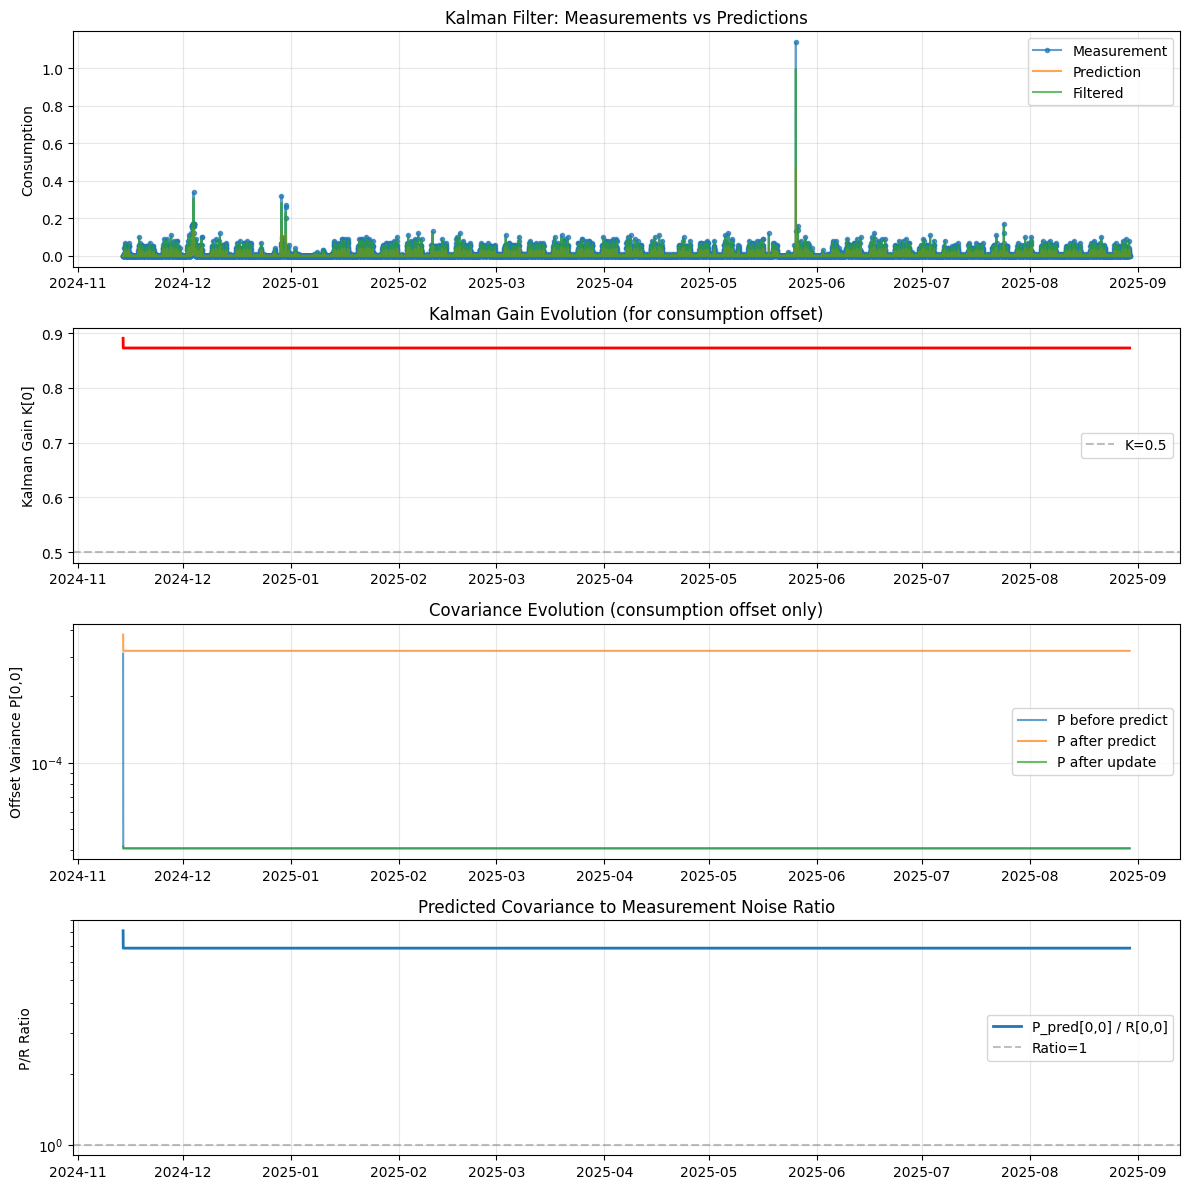


DIAGNOSTIC SUMMARY
K_offset - Mean: 0.8728, Min: 0.8728, Max: 0.8905
P_pred_offset_var - Mean: 3.210292e-04, Min: 3.210242e-04, Max: 3.806491e-04
P/R Ratio - Mean: 6.8596, Min: 6.8595, Max: 8.1336
Q/R Ratio (constant): 6.667634e+00


In [20]:
# Initialize filter
from kf_metrics import evaluate_kalman_filter, KalmanFilterMetrics

kf = WaterMeterKalmanFilter(A, Q, R, n_harmonics=3, seasonal_period=24.0)

df_filtered, metrics = evaluate_kalman_filter(kf, df2)

# Now you can plot the evolution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(12, 12))

# Plot 1: Measurements vs Predictions
axes[0].plot(df_filtered['timestamp'], df_filtered['Diff'], 
             label='Measurement', alpha=0.7, marker='.')
axes[0].plot(df_filtered['timestamp'], df_filtered['consumption_pred'], 
             label='Prediction', alpha=0.7)
axes[0].plot(df_filtered['timestamp'], df_filtered['consumption_filtered'], 
             label='Filtered', alpha=0.7)
axes[0].set_ylabel('Consumption')
axes[0].set_title('Kalman Filter: Measurements vs Predictions')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Kalman Gain for Offset
axes[1].plot(df_filtered['timestamp'], df_filtered['K_offset'], 
             color='red', linewidth=2)
axes[1].set_ylabel('Kalman Gain K[0]')
axes[1].set_title('Kalman Gain Evolution (for consumption offset)')
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='K=0.5')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Covariance Evolution
axes[2].plot(df_filtered['timestamp'], df_filtered['P_before_offset_var'], 
             label='P before predict', alpha=0.7)
axes[2].plot(df_filtered['timestamp'], df_filtered['P_pred_offset_var'], 
             label='P after predict', alpha=0.7)
axes[2].plot(df_filtered['timestamp'], df_filtered['P_updated_offset_var'], 
             label='P after update', alpha=0.7)
axes[2].set_ylabel('Offset Variance P[0,0]')
axes[2].set_title('Covariance Evolution (consumption offset only)')
axes[2].set_yscale('log')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Plot 4: Key Ratios
axes[3].plot(df_filtered['timestamp'], df_filtered['P_pred_to_R_ratio'], 
             label='P_pred[0,0] / R[0,0]', linewidth=2)
axes[3].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Ratio=1')
axes[3].set_ylabel('P/R Ratio')
axes[3].set_title('Predicted Covariance to Measurement Noise Ratio')
axes[3].set_yscale('log')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*70)
print("DIAGNOSTIC SUMMARY")
print("="*70)
print(f"K_offset - Mean: {df_filtered['K_offset'].mean():.4f}, "
      f"Min: {df_filtered['K_offset'].min():.4f}, "
      f"Max: {df_filtered['K_offset'].max():.4f}")
print(f"P_pred_offset_var - Mean: {df_filtered['P_pred_offset_var'].mean():.6e}, "
      f"Min: {df_filtered['P_pred_offset_var'].min():.6e}, "
      f"Max: {df_filtered['P_pred_offset_var'].max():.6e}")
print(f"P/R Ratio - Mean: {df_filtered['P_pred_to_R_ratio'].mean():.4f}, "
      f"Min: {df_filtered['P_pred_to_R_ratio'].min():.4f}, "
      f"Max: {df_filtered['P_pred_to_R_ratio'].max():.4f}")
print(f"Q/R Ratio (constant): {df_filtered['Q_to_R_ratio'].iloc[0]:.6e}")
print("="*70)


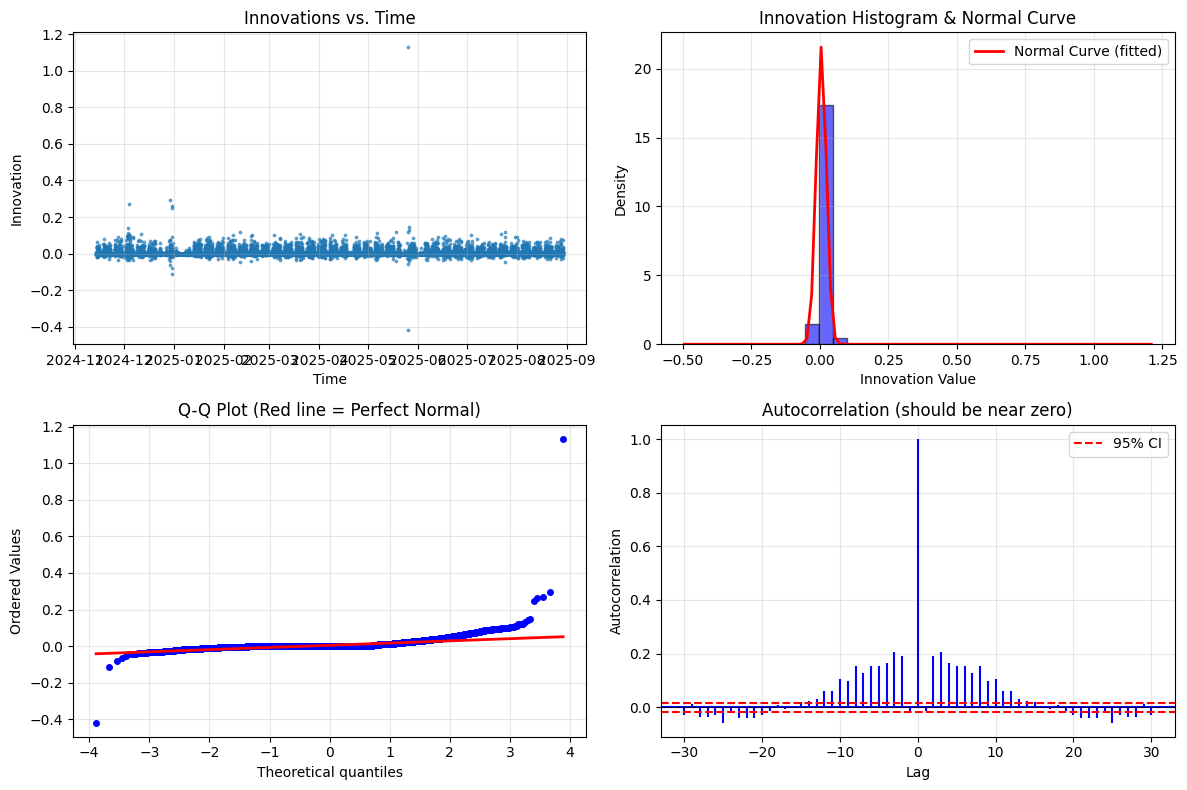

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

innovations = df_filtered['innovation'].values

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Time-series scatter (your existing plot)
axes[0, 0].scatter(df_filtered['timestamp'], innovations, s=3, alpha=0.6)
axes[0, 0].set_title('Innovations vs. Time')
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Innovation')
axes[0, 0].grid(True, alpha=0.3)

# 2. Histogram with normal curve overlay
axes[0, 1].hist(innovations, bins=30, density=True, alpha=0.6, color='blue', edgecolor='black')
xmin, xmax = axes[0, 1].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, np.mean(innovations), np.std(innovations))
axes[0, 1].plot(x, p, 'r', linewidth=2, label='Normal Curve (fitted)')
axes[0, 1].set_title('Innovation Histogram & Normal Curve')
axes[0, 1].set_xlabel('Innovation Value')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q Plot with reference line
stats.probplot(innovations, dist="norm", plot=axes[1, 0])
axes[1, 0].get_lines()[0].set_markerfacecolor('blue')
axes[1, 0].get_lines()[0].set_markeredgecolor('blue')
axes[1, 0].get_lines()[0].set_markersize(4)
axes[1, 0].get_lines()[1].set_color('red')  # Reference line (what normal should look like)
axes[1, 0].get_lines()[1].set_linewidth(2)
axes[1, 0].set_title('Q-Q Plot (Red line = Perfect Normal)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Autocorrelation plot
axes[1, 1].acorr(innovations - np.mean(innovations), maxlags=30, usevlines=True, color='blue')
axes[1, 1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[1, 1].axhline(y=1.96/np.sqrt(len(innovations)), color='r', linestyle='--', label='95% CI')
axes[1, 1].axhline(y=-1.96/np.sqrt(len(innovations)), color='r', linestyle='--')
axes[1, 1].set_title('Autocorrelation (should be near zero)')
axes[1, 1].set_xlabel('Lag')
axes[1, 1].set_ylabel('Autocorrelation')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [22]:

def plot_timeseries(df, value_columns, 
                   plot_type='line', 
                   date_range=None,
                   figsize=(15, 8),
                   title=None,
                   labels=None):
    """
    Plots time series data from a single DataFrame with a 'timestamp' column.
    Each column is plotted as a separate line with the same style but different colors.

    Args:
        df (pd.DataFrame): DataFrame with time series data (must have 'timestamp' column)
        value_columns (str or list of str): Name(s) of the value column(s) to plot
        plot_type (str): 'line', 'scatter', 'both', or 'resampled'
        date_range (tuple): (start_date, end_date) to filter the data
        figsize (tuple): Figure size (width, height)
        title (str): Custom plot title
        labels (list): Custom labels for each column (if None, uses column names)

    Returns:
        matplotlib.figure.Figure

    Examples:
        # Basic usage with multiple columns
        fig = plot_timeseries(df, ['Value1', 'Value2', 'Value3'])

        # With custom labels and plot type
        fig = plot_timeseries(df, ['Original', 'Resampled'], 
                             labels=['Raw Data', 'Hourly Avg'],
                             plot_type='line')

        # Comparing different preprocessing results
        fig = plot_timeseries(df, ['Raw', 'Hourly', 'Interpolated'],
                             labels=['Raw', 'Hourly', 'Interpolated'],
                             title='Data Preprocessing Comparison')
    """

    # Input validation
    if 'timestamp' not in df.columns:
        raise ValueError("DataFrame must have a 'timestamp' column")

    # Convert value_columns to list if it's a single string
    if isinstance(value_columns, str):
        value_columns = [value_columns]
    
    if not isinstance(value_columns, list):
        raise ValueError("value_columns must be a string or list of strings")

    if len(value_columns) == 0:
        raise ValueError("value_columns cannot be empty")

    # Check that all columns exist
    for col in value_columns:
        if col not in df.columns:
            raise ValueError(f"Column '{col}' not found in DataFrame")

    # Default labels if not provided
    if labels is None:
        labels = value_columns
    elif len(labels) != len(value_columns):
        raise ValueError("Number of labels must match number of columns")

    # Color palette for different lines - use tab10 colormap for up to 10 distinct colors
    if len(value_columns) < 5:
        colors_line = plt.cm.tab10([0, 3, 6, 9])
        colors_scatter = plt.cm.tab10([1, 4, 7, 8])
    else:
        # For more than 10 columns, use a continuous colormap
        colors_line = plt.cm.viridis(np.linspace(0, 1, len(value_columns)))
        colors_scatter = colors_line  # Use same colors for scatter when many columns

    # Prepare DataFrame
    df_plot = df.copy()
    
    # Ensure timestamp column is datetime
    df_plot['timestamp'] = pd.to_datetime(df_plot['timestamp'])

    # Filter by date range
    if date_range:
        start_date, end_date = date_range
        df_plot = df_plot[(df_plot['timestamp'] >= start_date) & 
                         (df_plot['timestamp'] <= end_date)]
        print(f"Filtered to date range: {date_range}")

    print(f"Plotting {len(df_plot)} points across {len(value_columns)} columns")

    # Create plot
    fig, ax = plt.subplots(figsize=figsize)

    if title is None:
        title = f"Time Series Plot ({len(df_plot):,} points)"

    # Plot each column
    for i, (col, label) in enumerate(zip(value_columns, labels)):
        # Skip if column has no valid data
        if df_plot[col].isna().all():
            print(f"Warning: Column '{col}' has no valid data")
            continue

        # Get appropriate colors
        color_line = colors_line[i]
        color_scatter = colors_scatter[i] if i < len(colors_scatter) else color_line

        # Plot types - all columns use same style but different colors
        if plot_type == 'line':
            ax.plot(df_plot['timestamp'], df_plot[col],
                    linewidth=1, alpha=1, color=color_line, label=label)

        elif plot_type == 'scatter':
            ax.scatter(df_plot['timestamp'], df_plot[col],
                       s=1, alpha=0.6, color=color_scatter, label=label)

        elif plot_type == 'both':
            ax.plot(df_plot['timestamp'], df_plot[col],
                    linewidth=0.8, alpha=0.8, color=color_line, label=f'{label} (Line)')
            ax.scatter(df_plot['timestamp'], df_plot[col],
                       s=5, alpha=0.6, color=color_scatter, label=f'{label} (Points)')

        elif plot_type == 'resampled':
            # For resampling, temporarily set timestamp as index
            df_temp = df_plot.set_index('timestamp')
            df_resampled = df_temp[col].resample('h').mean()
            ax.plot(df_resampled.index, df_resampled,
                    linewidth=1, color=color_line, label=f'{label} (Hourly Avg)')
            print(f"Column '{col}' resampled to hourly averages: {len(df_resampled)} points")

    # Labels and formatting
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('Value', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # Enhanced stats box for multiple columns
    stats_lines = []
    for col, label in zip(value_columns, labels):
        valid_data = df_plot[col].dropna()
        if len(valid_data) > 0:
            stats_lines.append(f"{label}:")
            stats_lines.append(f"  Min: {valid_data.min():.2f}")
            stats_lines.append(f"  Max: {valid_data.max():.2f}")
            stats_lines.append(f"  Mean: {valid_data.mean():.2f}")
            stats_lines.append(f"  Std: {valid_data.std():.2f}")
            stats_lines.append(f"  Valid: {len(valid_data)}/{len(df_plot)}")
            if col != value_columns[-1]:  # Add separator except for last
                stats_lines.append("---")

    stats_text = "\n".join(stats_lines)

    # Adjust stats box font size based on number of columns
    font_size = max(8, min(10, 10 - len(value_columns) // 3))

    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle='round',
            facecolor='wheat', alpha=0.8), fontsize=font_size)

    plt.tight_layout()
    plt.show()
    # return fig

Filtered to date range: ('2025-08-07', '2025-08-08')
Plotting 47 points across 3 columns


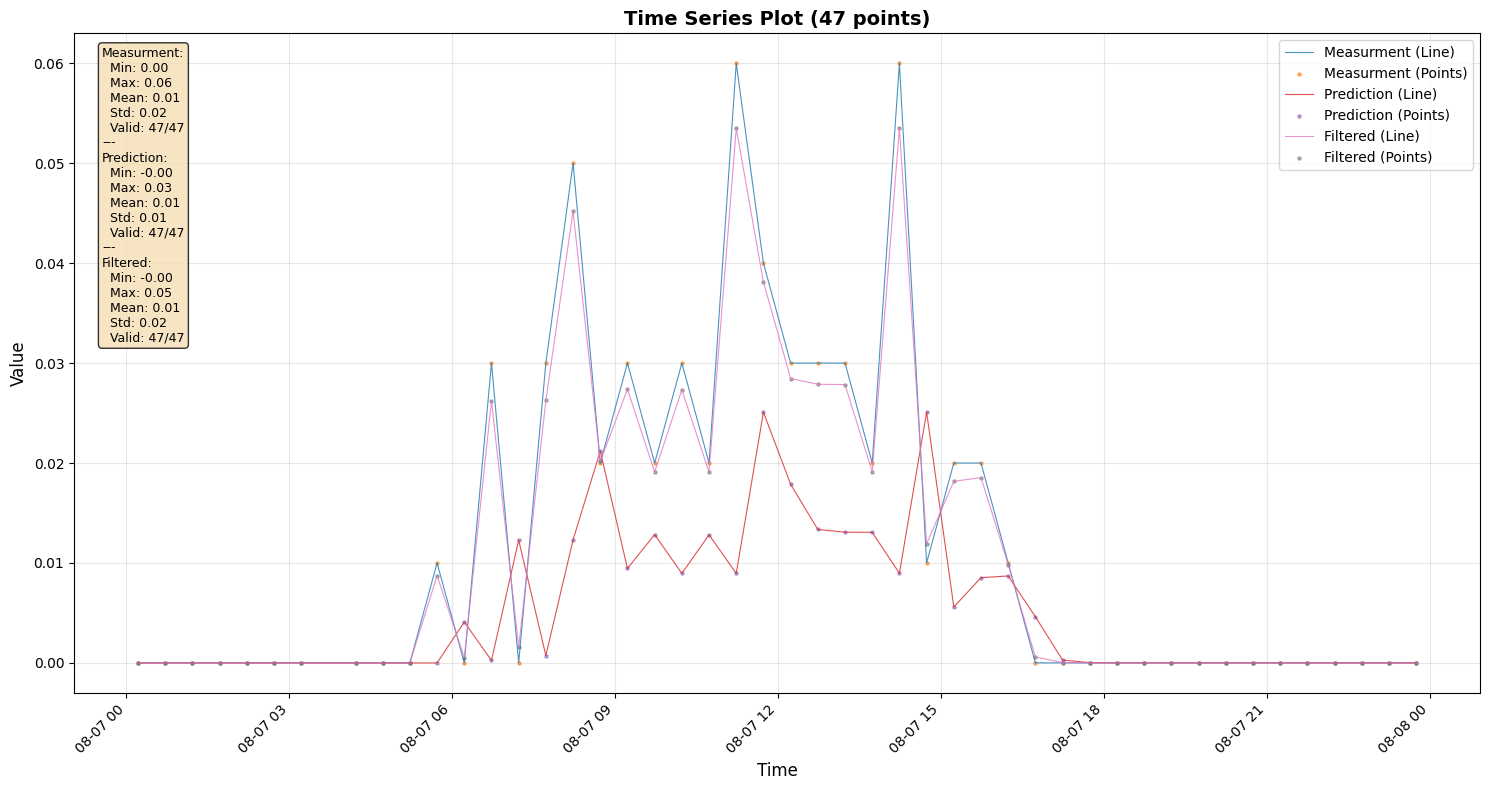

In [23]:
plot_timeseries(df_filtered, ['Diff', 'consumption_pred', 'consumption_filtered'], date_range=("2025-08-07", "2025-08-08"), plot_type="both", labels=['Measurment', 'Prediction', 'Filtered'])

In [45]:
estimator = KalmanFilterWRLSEstimator(lambda_forget=0.9999)
n_harmonics=1
df_artificial = pd.read_csv('./data/artificial_water_consumption_3months.csv')

A, Q, R, metadata = estimator.estimate_from_dataframe(
    df_artificial,
    expected_interval_seconds=30*60,
    n_harmonics=n_harmonics,
    tolerance_percent=10.0,
    verbose=True
)
print(R)

kf_artificial = WaterMeterKalmanFilter(A, Q, R, n_harmonics=n_harmonics, seasonal_period=24.0)

✓ Data Processing Summary:
  Time span: 2159.5 hours
  Expected readings (based on 1800s interval): 4320
  Expected pairs: 4319
  Valid pairs found: 4319
  Data validity: 100.0%


Starting WRLS estimation...
  State dimension: 3
  Forgetting factor λ = 0.9999

  Processed 100/4319 updates... Max |eigval(A)| = 1.0000
  Processed 200/4319 updates... Max |eigval(A)| = 1.0000
  Processed 300/4319 updates... Max |eigval(A)| = 1.0000
  Processed 400/4319 updates... Max |eigval(A)| = 1.0000
  Processed 500/4319 updates... Max |eigval(A)| = 1.0000
  Processed 600/4319 updates... Max |eigval(A)| = 1.0000
  Processed 700/4319 updates... Max |eigval(A)| = 1.0000
  Processed 800/4319 updates... Max |eigval(A)| = 1.0000
  Processed 900/4319 updates... Max |eigval(A)| = 1.0000
  Processed 1000/4319 updates... Max |eigval(A)| = 1.0000
  Processed 1100/4319 updates... Max |eigval(A)| = 1.0000
  Processed 1200/4319 updates... Max |eigval(A)| = 1.0000
  Processed 1300/4319 updates... Max |eigval(A)| = 1


Kalman Filter Performance Metrics

Data Summary:
----------------------------------------------------------------------
  n_nonzero_measurements                       : 4065
  n_total_measurements                         : 4320
  nonzero_percentage                           : 94.097222

Prediction Accuracy (All Data):
----------------------------------------------------------------------
  MAE_prediction                               : 0.012642
  RMSE_prediction                              : 0.016486
  ME_prediction                                : 3.128983e-03
  MedAE_prediction                             : 9.946226e-03
  MAPE_prediction                              : 1.246226e+09
  NRMSE_prediction                             : 0.490921
  R2_prediction                                : 0.758996

Prediction Accuracy (Non-Zero Only):
----------------------------------------------------------------------
  MAE_prediction_nonzero                       : 0.012111
  RMSE_prediction_nonze

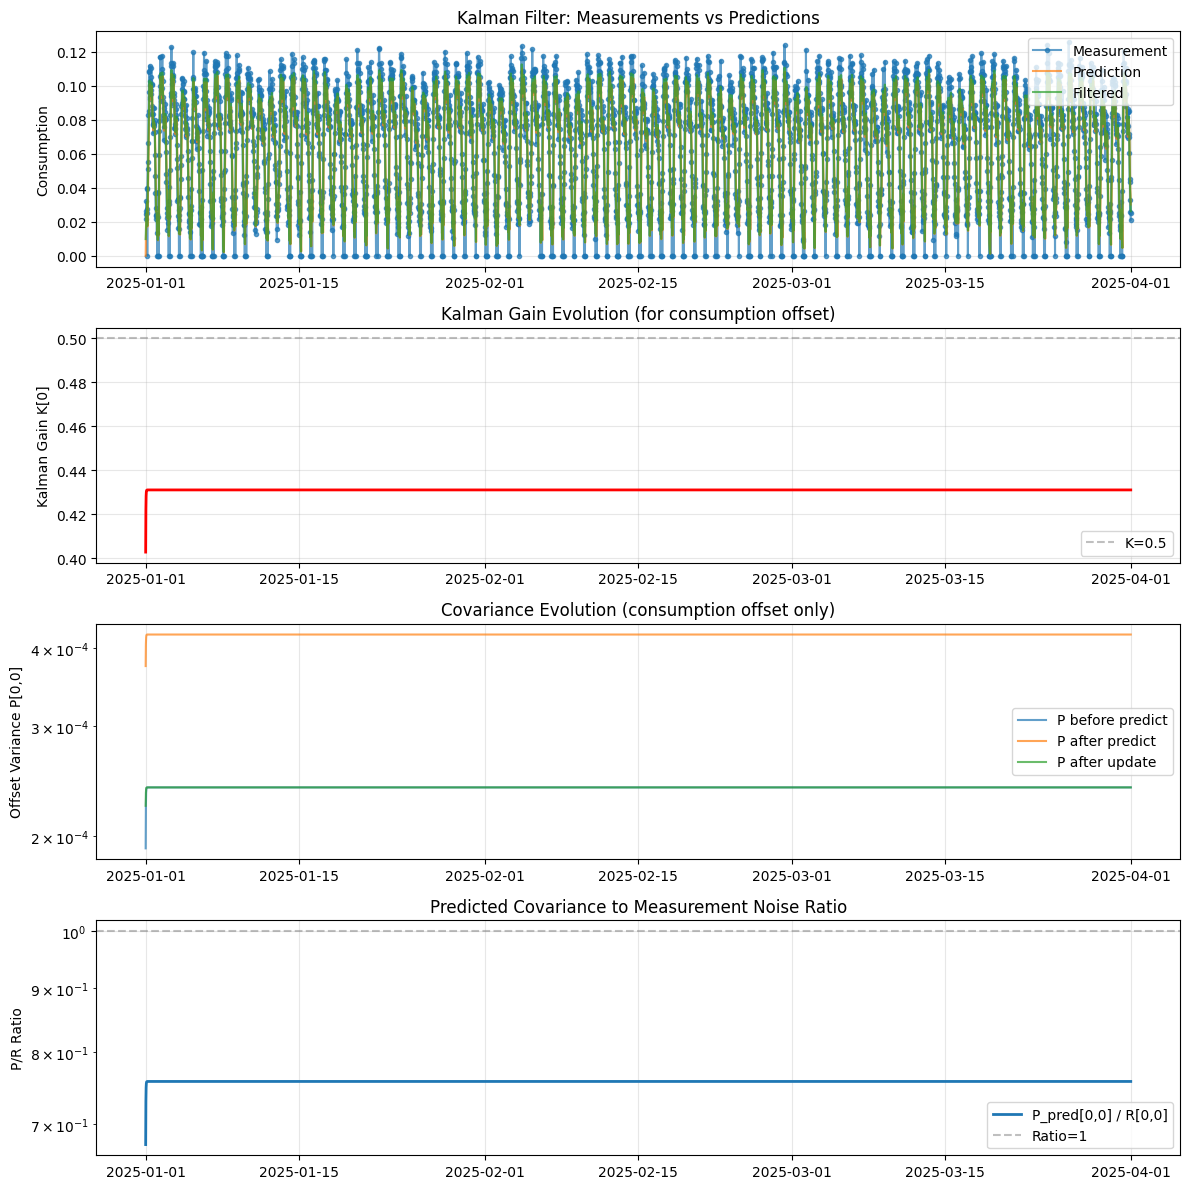


DIAGNOSTIC SUMMARY
K_offset - Mean: 0.4310, Min: 0.4028, Max: 0.4310
P_pred_offset_var - Mean: 4.210064e-04, Min: 3.747863e-04, Max: 4.210221e-04
P/R Ratio - Mean: 0.7576, Min: 0.6744, Max: 0.7576
Q/R Ratio (constant): 3.442713e-01


In [25]:
df_filtered_artificial, metrics = evaluate_kalman_filter(kf_artificial, df_artificial)

fig, axes = plt.subplots(4, 1, figsize=(12, 12))

# Plot 1: Measurements vs Predictions
axes[0].plot(df_filtered_artificial['timestamp'], df_filtered_artificial['Diff'], 
             label='Measurement', alpha=0.7, marker='.')
axes[0].plot(df_filtered_artificial['timestamp'], df_filtered_artificial['consumption_pred'], 
             label='Prediction', alpha=0.7)
axes[0].plot(df_filtered_artificial['timestamp'], df_filtered_artificial['consumption_filtered'], 
             label='Filtered', alpha=0.7)
axes[0].set_ylabel('Consumption')
axes[0].set_title('Kalman Filter: Measurements vs Predictions')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Kalman Gain for Offset
axes[1].plot(df_filtered_artificial['timestamp'], df_filtered_artificial['K_offset'], 
             color='red', linewidth=2)
axes[1].set_ylabel('Kalman Gain K[0]')
axes[1].set_title('Kalman Gain Evolution (for consumption offset)')
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='K=0.5')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Covariance Evolution
axes[2].plot(df_filtered_artificial['timestamp'], df_filtered_artificial['P_before_offset_var'], 
             label='P before predict', alpha=0.7)
axes[2].plot(df_filtered_artificial['timestamp'], df_filtered_artificial['P_pred_offset_var'], 
             label='P after predict', alpha=0.7)
axes[2].plot(df_filtered_artificial['timestamp'], df_filtered_artificial['P_updated_offset_var'], 
             label='P after update', alpha=0.7)
axes[2].set_ylabel('Offset Variance P[0,0]')
axes[2].set_title('Covariance Evolution (consumption offset only)')
axes[2].set_yscale('log')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Plot 4: Key Ratios
axes[3].plot(df_filtered_artificial['timestamp'], df_filtered_artificial['P_pred_to_R_ratio'], 
             label='P_pred[0,0] / R[0,0]', linewidth=2)
axes[3].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Ratio=1')
axes[3].set_ylabel('P/R Ratio')
axes[3].set_title('Predicted Covariance to Measurement Noise Ratio')
axes[3].set_yscale('log')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*70)
print("DIAGNOSTIC SUMMARY")
print("="*70)
print(f"K_offset - Mean: {df_filtered_artificial['K_offset'].mean():.4f}, "
      f"Min: {df_filtered_artificial['K_offset'].min():.4f}, "
      f"Max: {df_filtered_artificial['K_offset'].max():.4f}")
print(f"P_pred_offset_var - Mean: {df_filtered_artificial['P_pred_offset_var'].mean():.6e}, "
      f"Min: {df_filtered_artificial['P_pred_offset_var'].min():.6e}, "
      f"Max: {df_filtered_artificial['P_pred_offset_var'].max():.6e}")
print(f"P/R Ratio - Mean: {df_filtered_artificial['P_pred_to_R_ratio'].mean():.4f}, "
      f"Min: {df_filtered_artificial['P_pred_to_R_ratio'].min():.4f}, "
      f"Max: {df_filtered_artificial['P_pred_to_R_ratio'].max():.4f}")
print(f"Q/R Ratio (constant): {df_filtered_artificial['Q_to_R_ratio'].iloc[0]:.6e}")
print("="*70)


Filtered to date range: ('2025-03-15', '2025-03-17')
Plotting 97 points across 3 columns


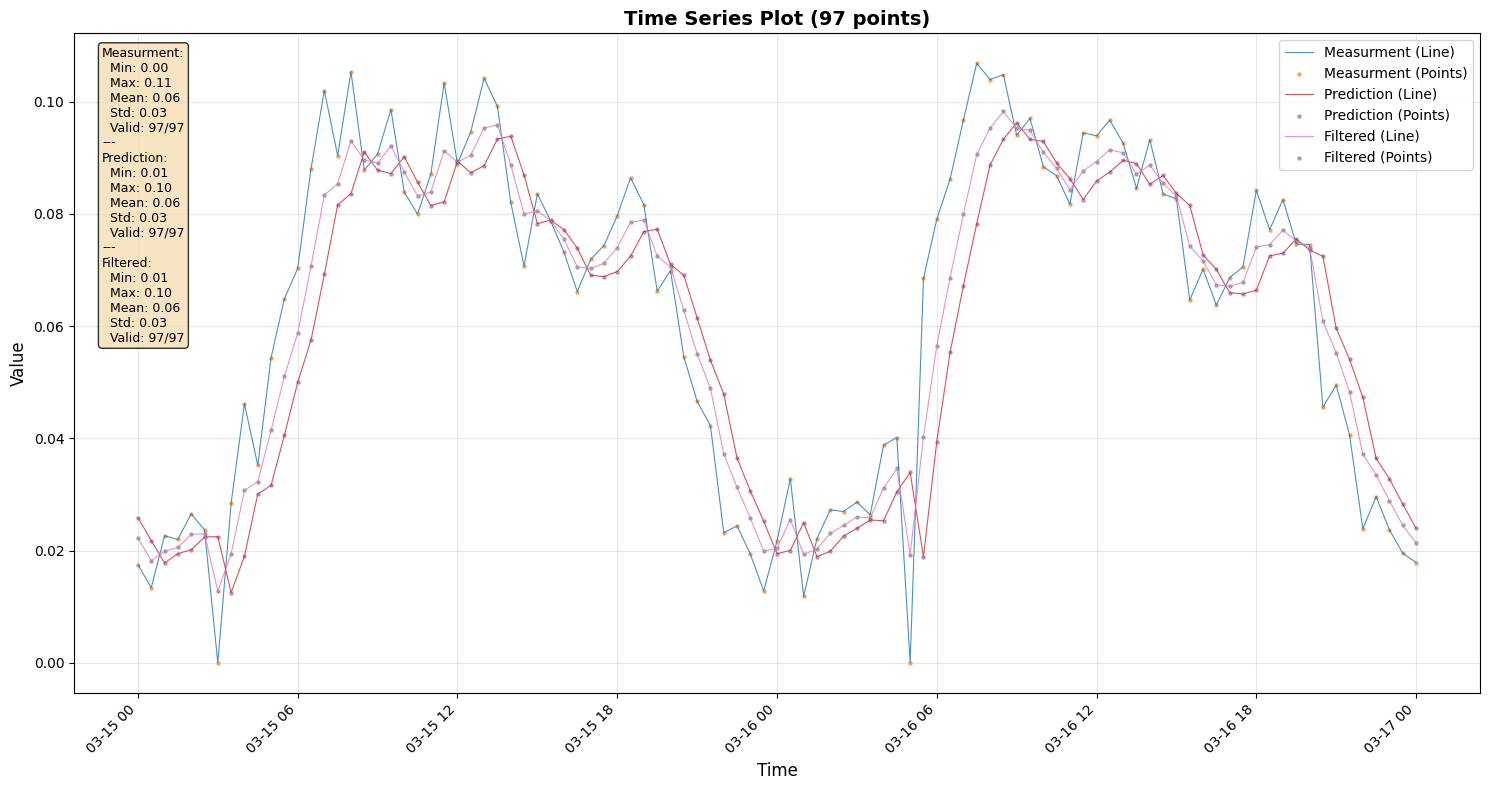

In [26]:
plot_timeseries(df_filtered_artificial, ['Diff', 'consumption_pred', 'consumption_filtered'], date_range=("2025-03-15", "2025-03-17"), plot_type="both", labels=['Measurment', 'Prediction', 'Filtered'])

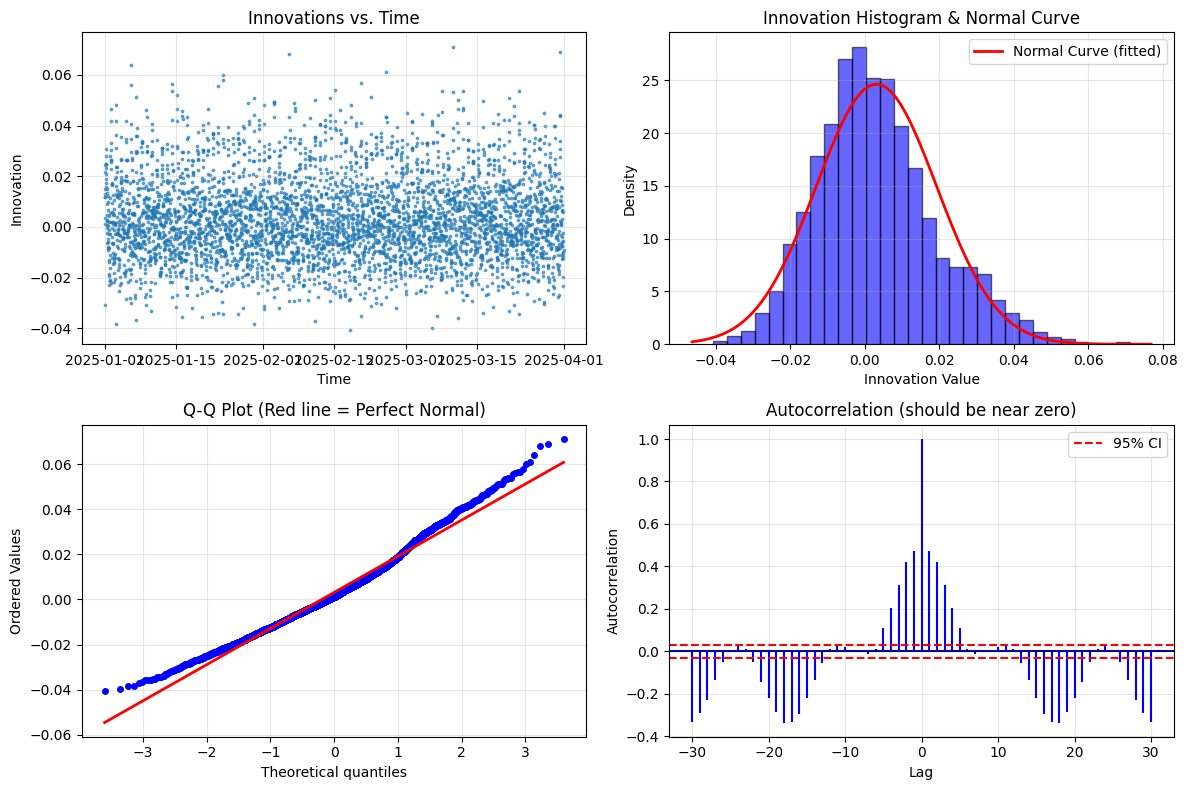

In [27]:
innovations_artificial = df_filtered_artificial['innovation'].values

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Time-series scatter (your existing plot)
axes[0, 0].scatter(df_filtered_artificial['timestamp'], innovations_artificial, s=3, alpha=0.6)
axes[0, 0].set_title('Innovations vs. Time')
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Innovation')
axes[0, 0].grid(True, alpha=0.3)

# 2. Histogram with normal curve overlay
axes[0, 1].hist(innovations_artificial, bins=30, density=True, alpha=0.6, color='blue', edgecolor='black')
xmin, xmax = axes[0, 1].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, np.mean(innovations_artificial), np.std(innovations_artificial))
axes[0, 1].plot(x, p, 'r', linewidth=2, label='Normal Curve (fitted)')
axes[0, 1].set_title('Innovation Histogram & Normal Curve')
axes[0, 1].set_xlabel('Innovation Value')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q Plot with reference line
stats.probplot(innovations_artificial, dist="norm", plot=axes[1, 0])
axes[1, 0].get_lines()[0].set_markerfacecolor('blue')
axes[1, 0].get_lines()[0].set_markeredgecolor('blue')
axes[1, 0].get_lines()[0].set_markersize(4)
axes[1, 0].get_lines()[1].set_color('red')  # Reference line (what normal should look like)
axes[1, 0].get_lines()[1].set_linewidth(2)
axes[1, 0].set_title('Q-Q Plot (Red line = Perfect Normal)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Autocorrelation plot
axes[1, 1].acorr(innovations_artificial - np.mean(innovations_artificial), maxlags=30, usevlines=True, color='blue')
axes[1, 1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[1, 1].axhline(y=1.96/np.sqrt(len(innovations_artificial)), color='r', linestyle='--', label='95% CI')
axes[1, 1].axhline(y=-1.96/np.sqrt(len(innovations_artificial)), color='r', linestyle='--')
axes[1, 1].set_title('Autocorrelation (should be near zero)')
axes[1, 1].set_xlabel('Lag')
axes[1, 1].set_ylabel('Autocorrelation')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [46]:
from kf_wrls_seasonal_lags import KalmanFilterWRLSEstimatorSeasonalLags
from kf_seasonal_lags import WaterMeterKalmanFilterSeasonalLags

estimator = KalmanFilterWRLSEstimatorSeasonalLags(lambda_forget=0.9999)
df_artificial = pd.read_csv('./data/artificial_water_consumption_3months.csv')

A, Q, R, metadata = estimator.estimate_from_dataframe(
    df_artificial,
    expected_interval_seconds=30*60,
    tolerance_percent=10.0,
    verbose=True
)
print(R)
kf_artificial = WaterMeterKalmanFilterSeasonalLags(A, Q, R)

✓ Data Processing Summary:
  Time span: 2159.5 hours
  Expected readings (based on 1800s interval): 4320
  Seasonal period: 24.0 hours
  State dimension (measurements per period): 48
  Expected pairs: 4272
  Valid pairs found: 4271
  Data validity: 100.0%


Starting WRLS estimation...
  State dimension: 48
  Forgetting factor λ = 0.9999

  Processed 100/4271 updates... Max |eigval(A)| = 1.0007


c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\test\kf_wrls_seasonal_lags.py:410: UserWarning: Potentially unstable A detected at update 100. Max eigenvalue: 1.0007
  warnings.warn(f"Potentially unstable A detected at update {idx + 1}. Max eigenvalue: {max_eig:.4f}")
c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\test\kf_wrls_seasonal_lags.py:410: UserWarning: Potentially unstable A detected at update 200. Max eigenvalue: 1.0005
  warnings.warn(f"Potentially unstable A detected at update {idx + 1}. Max eigenvalue: {max_eig:.4f}")


  Processed 200/4271 updates... Max |eigval(A)| = 1.0005
  Processed 300/4271 updates... Max |eigval(A)| = 1.0003


c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\test\kf_wrls_seasonal_lags.py:410: UserWarning: Potentially unstable A detected at update 300. Max eigenvalue: 1.0003
  warnings.warn(f"Potentially unstable A detected at update {idx + 1}. Max eigenvalue: {max_eig:.4f}")
c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\test\kf_wrls_seasonal_lags.py:410: UserWarning: Potentially unstable A detected at update 400. Max eigenvalue: 1.0001
  warnings.warn(f"Potentially unstable A detected at update {idx + 1}. Max eigenvalue: {max_eig:.4f}")


  Processed 400/4271 updates... Max |eigval(A)| = 1.0001
  Processed 500/4271 updates... Max |eigval(A)| = 0.9999
  Processed 600/4271 updates... Max |eigval(A)| = 0.9999
  Processed 700/4271 updates... Max |eigval(A)| = 1.0000
  Processed 800/4271 updates... Max |eigval(A)| = 0.9999
  Processed 900/4271 updates... Max |eigval(A)| = 1.0000
  Processed 1000/4271 updates... Max |eigval(A)| = 1.0000
  Processed 1100/4271 updates... Max |eigval(A)| = 1.0000


c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\test\kf_wrls_seasonal_lags.py:410: UserWarning: Potentially unstable A detected at update 1000. Max eigenvalue: 1.0000
  warnings.warn(f"Potentially unstable A detected at update {idx + 1}. Max eigenvalue: {max_eig:.4f}")


  Processed 1200/4271 updates... Max |eigval(A)| = 0.9999
  Processed 1300/4271 updates... Max |eigval(A)| = 1.0000
  Processed 1400/4271 updates... Max |eigval(A)| = 1.0000
  Processed 1500/4271 updates... Max |eigval(A)| = 0.9999
  Processed 1600/4271 updates... Max |eigval(A)| = 1.0000
  Processed 1700/4271 updates... Max |eigval(A)| = 1.0000


c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\test\kf_wrls_seasonal_lags.py:410: UserWarning: Potentially unstable A detected at update 1600. Max eigenvalue: 1.0000
  warnings.warn(f"Potentially unstable A detected at update {idx + 1}. Max eigenvalue: {max_eig:.4f}")


  Processed 1800/4271 updates... Max |eigval(A)| = 0.9999
  Processed 1900/4271 updates... Max |eigval(A)| = 1.0000
  Processed 2000/4271 updates... Max |eigval(A)| = 1.0000
  Processed 2100/4271 updates... Max |eigval(A)| = 1.0000
  Processed 2200/4271 updates... Max |eigval(A)| = 0.9999
  Processed 2300/4271 updates... Max |eigval(A)| = 1.0000
  Processed 2400/4271 updates... Max |eigval(A)| = 1.0000
  Processed 2500/4271 updates... Max |eigval(A)| = 0.9999
  Processed 2600/4271 updates... Max |eigval(A)| = 1.0000
  Processed 2700/4271 updates... Max |eigval(A)| = 1.0000
  Processed 2800/4271 updates... Max |eigval(A)| = 1.0000
  Processed 2900/4271 updates... Max |eigval(A)| = 1.0000
  Processed 3000/4271 updates... Max |eigval(A)| = 1.0000
  Processed 3100/4271 updates... Max |eigval(A)| = 1.0000
  Processed 3200/4271 updates... Max |eigval(A)| = 1.0000
  Processed 3300/4271 updates... Max |eigval(A)| = 1.0000
  Processed 3400/4271 updates... Max |eigval(A)| = 1.0000
  Processed 35


Kalman Filter Performance Metrics

Data Summary:
----------------------------------------------------------------------
  n_nonzero_measurements                       : 3610
  n_total_measurements                         : 3840
  nonzero_percentage                           : 94.010417

Prediction Accuracy (All Data):
----------------------------------------------------------------------
  MAE_prediction                               : 6.992593e-03
  RMSE_prediction                              : 9.936271e-03
  ME_prediction                                : 5.460909e-05
  MedAE_prediction                             : 5.233008e-03
  MAPE_prediction                              : 1.563434e+09
  NRMSE_prediction                             : 0.296492
  R2_prediction                                : 0.912092

Prediction Accuracy (Non-Zero Only):
----------------------------------------------------------------------
  MAE_prediction_nonzero                       : 5.756771e-03
  RMSE_pred

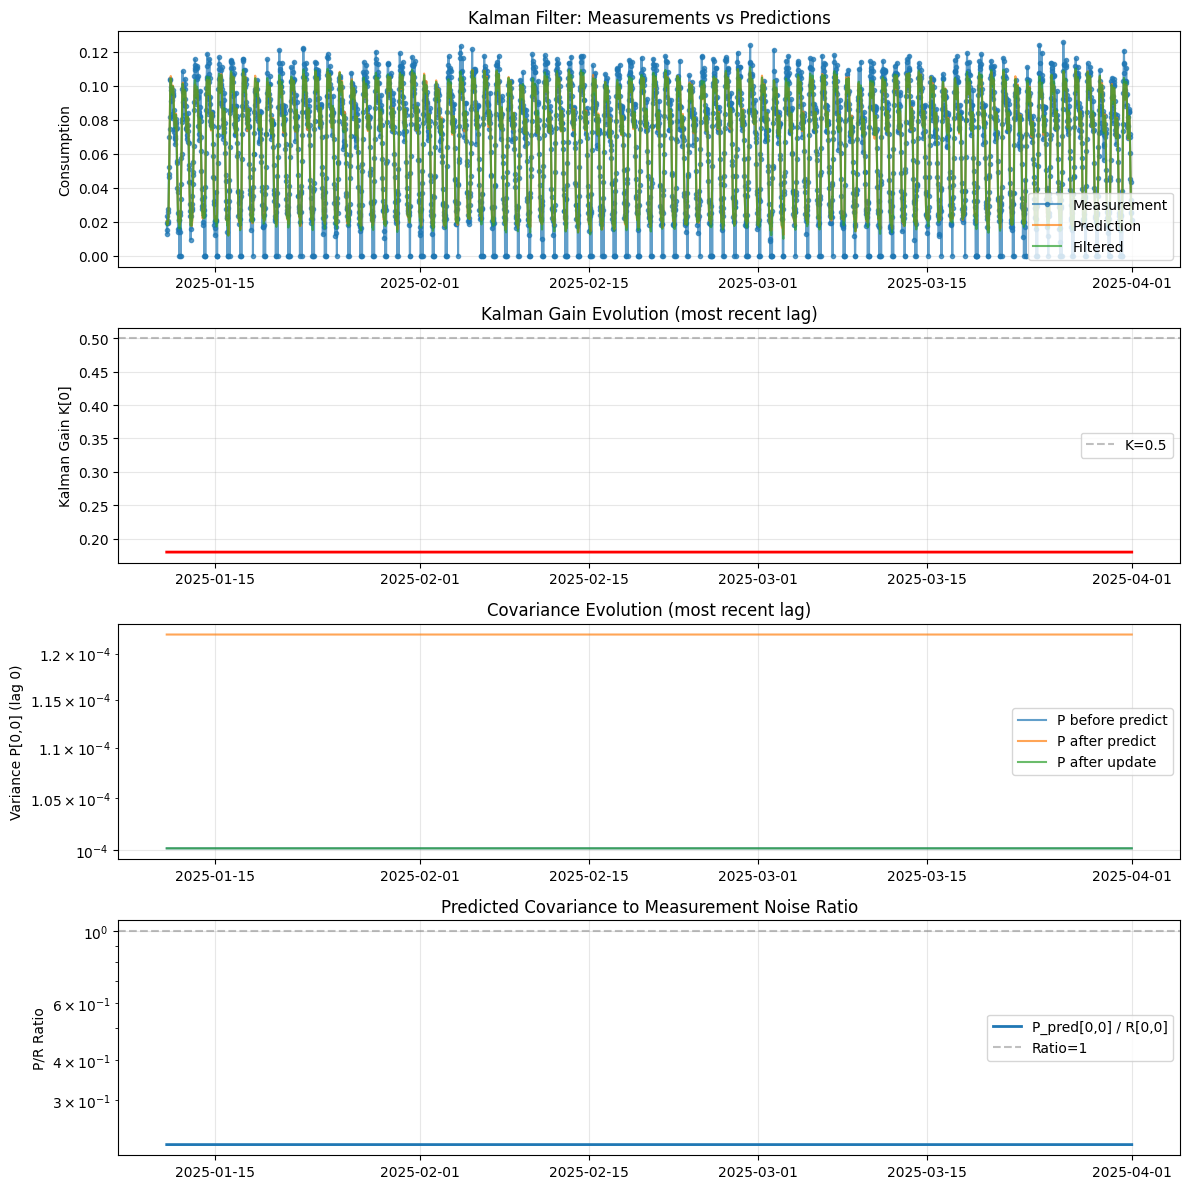


DIAGNOSTIC SUMMARY
K_lag0   - Mean: 0.1797, Min: 0.1797, Max: 0.1797
P_pred_lag0_var - Mean: 1.221438e-04, Min: 1.221436e-04, Max: 1.221438e-04
P/R Ratio - Mean: 0.2191, Min: 0.2191, Max: 0.2191
Q/R Ratio (constant): 3.740493e-03


In [29]:
df_filtered_artificial = kf_artificial.filter_dataframe(
        df_artificial,
        anomaly_threshold=3.0,
        return_diagnostics=True
)

df_filtered_artificial = df_filtered_artificial[48*10:]

metrics = KalmanFilterMetrics.compute_all_metrics(
    df_filtered_artificial,
    nonzero_threshold=0.01
)
KalmanFilterMetrics.print_metrics_report(metrics)


fig, axes = plt.subplots(4, 1, figsize=(12, 12))

# Plot 1: Measurements vs Predictions
axes[0].plot(df_filtered_artificial['timestamp'], df_filtered_artificial['Diff'], 
             label='Measurement', alpha=0.7, marker='.')
axes[0].plot(df_filtered_artificial['timestamp'], df_filtered_artificial['consumption_pred'], 
             label='Prediction', alpha=0.7)
axes[0].plot(df_filtered_artificial['timestamp'], df_filtered_artificial['consumption_filtered'], 
             label='Filtered', alpha=0.7)
axes[0].set_ylabel('Consumption')
axes[0].set_title('Kalman Filter: Measurements vs Predictions')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Kalman Gain for Most Recent Lag
axes[1].plot(df_filtered_artificial['timestamp'], df_filtered_artificial['K_lag0'], 
             color='red', linewidth=2)
axes[1].set_ylabel('Kalman Gain K[0]')
axes[1].set_title('Kalman Gain Evolution (most recent lag)')
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='K=0.5')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Covariance Evolution (most recent lag)
axes[2].plot(df_filtered_artificial['timestamp'], df_filtered_artificial['P_before_lag0_var'], 
             label='P before predict', alpha=0.7)
axes[2].plot(df_filtered_artificial['timestamp'], df_filtered_artificial['P_pred_lag0_var'], 
             label='P after predict', alpha=0.7)
axes[2].plot(df_filtered_artificial['timestamp'], df_filtered_artificial['P_updated_lag0_var'], 
             label='P after update', alpha=0.7)
axes[2].set_ylabel('Variance P[0,0] (lag 0)')
axes[2].set_title('Covariance Evolution (most recent lag)')
axes[2].set_yscale('log')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Plot 4: Key Ratios
axes[3].plot(df_filtered_artificial['timestamp'], df_filtered_artificial['P_pred_to_R_ratio'], 
             label='P_pred[0,0] / R[0,0]', linewidth=2)
axes[3].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Ratio=1')
axes[3].set_ylabel('P/R Ratio')
axes[3].set_title('Predicted Covariance to Measurement Noise Ratio')
axes[3].set_yscale('log')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("DIAGNOSTIC SUMMARY")
print("="*70)
print(f"K_lag0   - Mean: {df_filtered_artificial['K_lag0'].mean():.4f}, "
      f"Min: {df_filtered_artificial['K_lag0'].min():.4f}, "
      f"Max: {df_filtered_artificial['K_lag0'].max():.4f}")

print(f"P_pred_lag0_var - Mean: {df_filtered_artificial['P_pred_lag0_var'].mean():.6e}, "
      f"Min: {df_filtered_artificial['P_pred_lag0_var'].min():.6e}, "
      f"Max: {df_filtered_artificial['P_pred_lag0_var'].max():.6e}")

print(f"P/R Ratio - Mean: {df_filtered_artificial['P_pred_to_R_ratio'].mean():.4f}, "
      f"Min: {df_filtered_artificial['P_pred_to_R_ratio'].min():.4f}, "
      f"Max: {df_filtered_artificial['P_pred_to_R_ratio'].max():.4f}")

print(f"Q/R Ratio (constant): {df_filtered_artificial['Q_to_R_ratio'].iloc[0]:.6e}")
print("="*70)


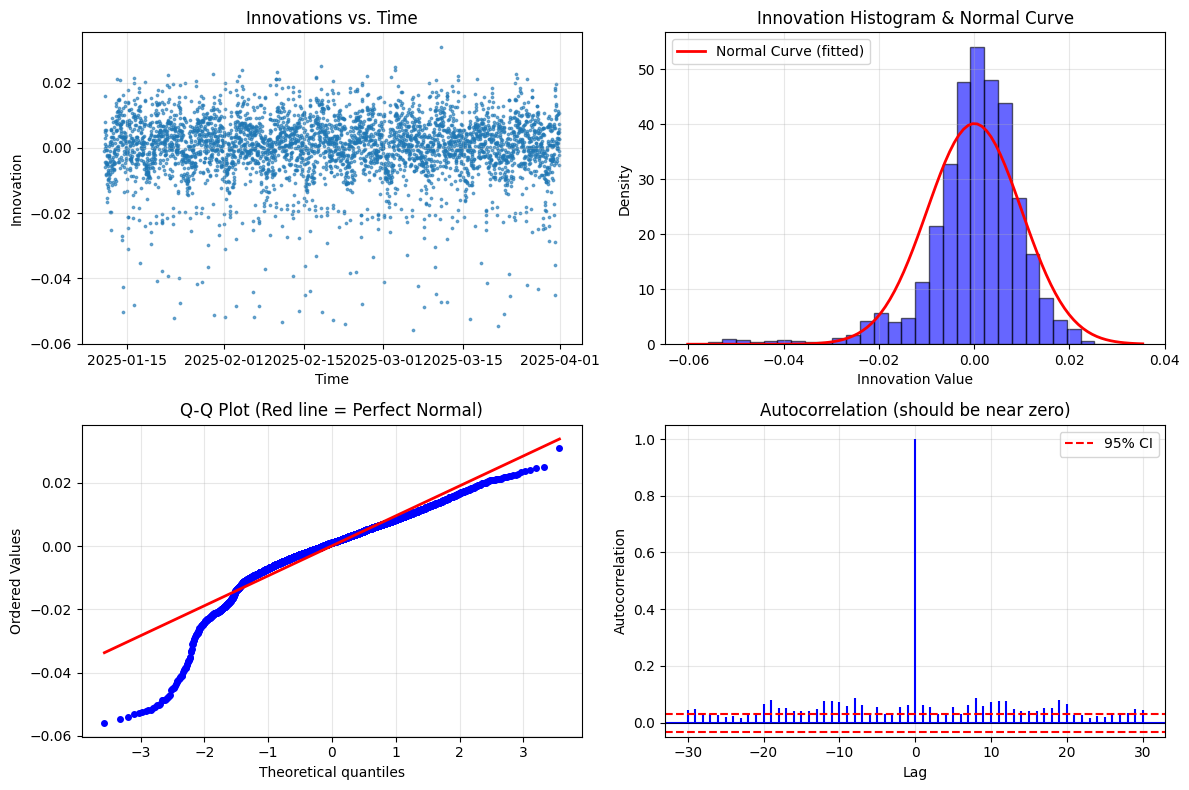

In [30]:
innovations_artificial = df_filtered_artificial['innovation'].values

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Time-series scatter (your existing plot)
axes[0, 0].scatter(df_filtered_artificial['timestamp'], innovations_artificial, s=3, alpha=0.6)
axes[0, 0].set_title('Innovations vs. Time')
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Innovation')
axes[0, 0].grid(True, alpha=0.3)

# 2. Histogram with normal curve overlay
axes[0, 1].hist(innovations_artificial, bins=30, density=True, alpha=0.6, color='blue', edgecolor='black')
xmin, xmax = axes[0, 1].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, np.mean(innovations_artificial), np.std(innovations_artificial))
axes[0, 1].plot(x, p, 'r', linewidth=2, label='Normal Curve (fitted)')
axes[0, 1].set_title('Innovation Histogram & Normal Curve')
axes[0, 1].set_xlabel('Innovation Value')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q Plot with reference line
stats.probplot(innovations_artificial, dist="norm", plot=axes[1, 0])
axes[1, 0].get_lines()[0].set_markerfacecolor('blue')
axes[1, 0].get_lines()[0].set_markeredgecolor('blue')
axes[1, 0].get_lines()[0].set_markersize(4)
axes[1, 0].get_lines()[1].set_color('red')  # Reference line (what normal should look like)
axes[1, 0].get_lines()[1].set_linewidth(2)
axes[1, 0].set_title('Q-Q Plot (Red line = Perfect Normal)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Autocorrelation plot
axes[1, 1].acorr(innovations_artificial - np.mean(innovations_artificial), maxlags=30, usevlines=True, color='blue')
axes[1, 1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[1, 1].axhline(y=1.96/np.sqrt(len(innovations_artificial)), color='r', linestyle='--', label='95% CI')
axes[1, 1].axhline(y=-1.96/np.sqrt(len(innovations_artificial)), color='r', linestyle='--')
axes[1, 1].set_title('Autocorrelation (should be near zero)')
axes[1, 1].set_xlabel('Lag')
axes[1, 1].set_ylabel('Autocorrelation')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Filtered to date range: ('2025-03-15', '2025-03-17')
Plotting 97 points across 3 columns


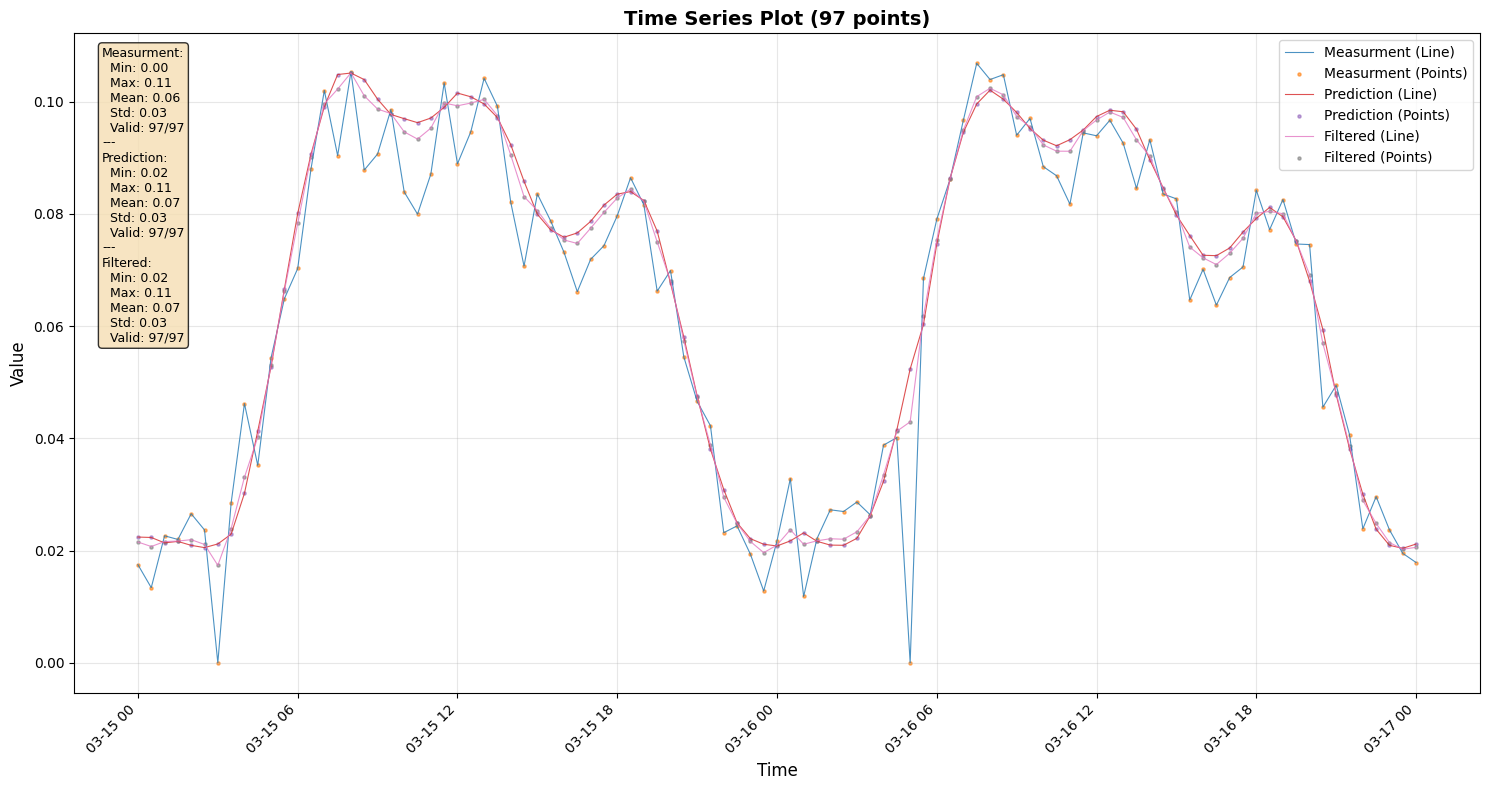

In [31]:
plot_timeseries(df_filtered_artificial, ['Diff', 'consumption_pred', 'consumption_filtered'], date_range=("2025-03-15", "2025-03-17"), plot_type="both", labels=['Measurment', 'Prediction', 'Filtered'])

In [32]:
import statsmodels.api as sm

In [33]:
endog = df_artificial['Diff']

mod = sm.tsa.UnobservedComponents(
    endog,
    level='fixed intercept',    # Or use 'local level' if slight drift is possible
    seasonal=48,               # Set to match your period length
    stochastic_seasonal=True   # Allow model to estimate seasonal effects
)
res = mod.fit()
print(res.summary())


c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\.venv\Lib\site-packages\statsmodels\tsa\filters\hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)


                            Unobserved Components Results                            
Dep. Variable:                          Diff   No. Observations:                 4320
Model:                       fixed intercept   Log Likelihood                2533.824
                   + stochastic seasonal(48)   AIC                          -5065.648
Date:                       Wed, 19 Nov 2025   BIC                          -5059.288
Time:                               14:56:31   HQIC                         -5063.401
Sample:                                    0                                         
                                      - 4320                                         
Covariance Type:                         opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
sigma2.seasonal     0.0178      0.000     37.733      0.00

c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\.venv\Lib\site-packages\statsmodels\tsa\statespace\structural.py:1738: RuntimeWarning: invalid value encountered in sqrt
  std_errors = np.sqrt(component_bunch['%s_cov' % which])


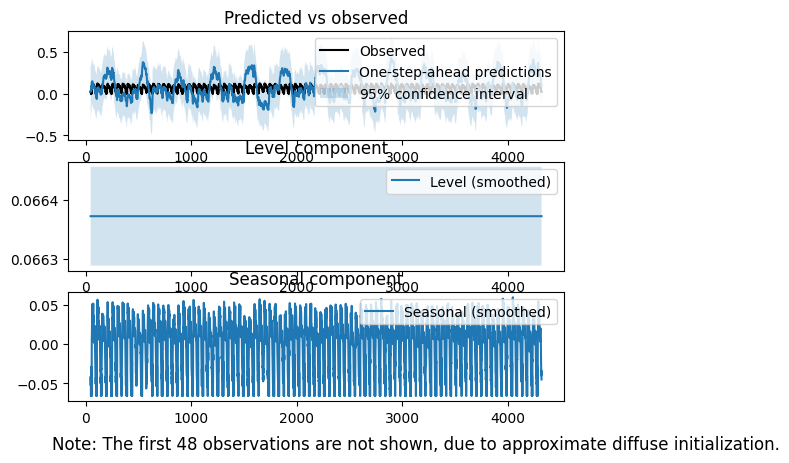

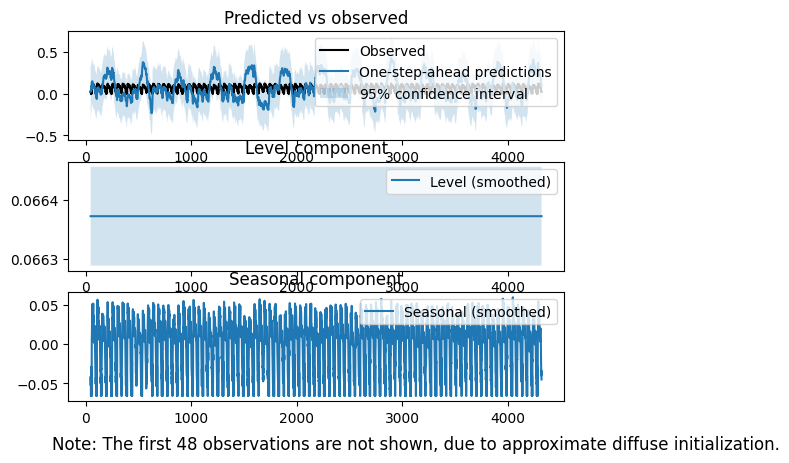

In [34]:
res.plot_components()  # Visualizes the estimated seasonal pattern

c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\.venv\Lib\site-packages\statsmodels\tsa\filters\hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)


State dimension: 48
T_matrix shape: (48, 48)
Z_matrix shape: (1, 48)
Q_matrix shape: (1, 1)

Detected 10 anomalies out of 3840 observations


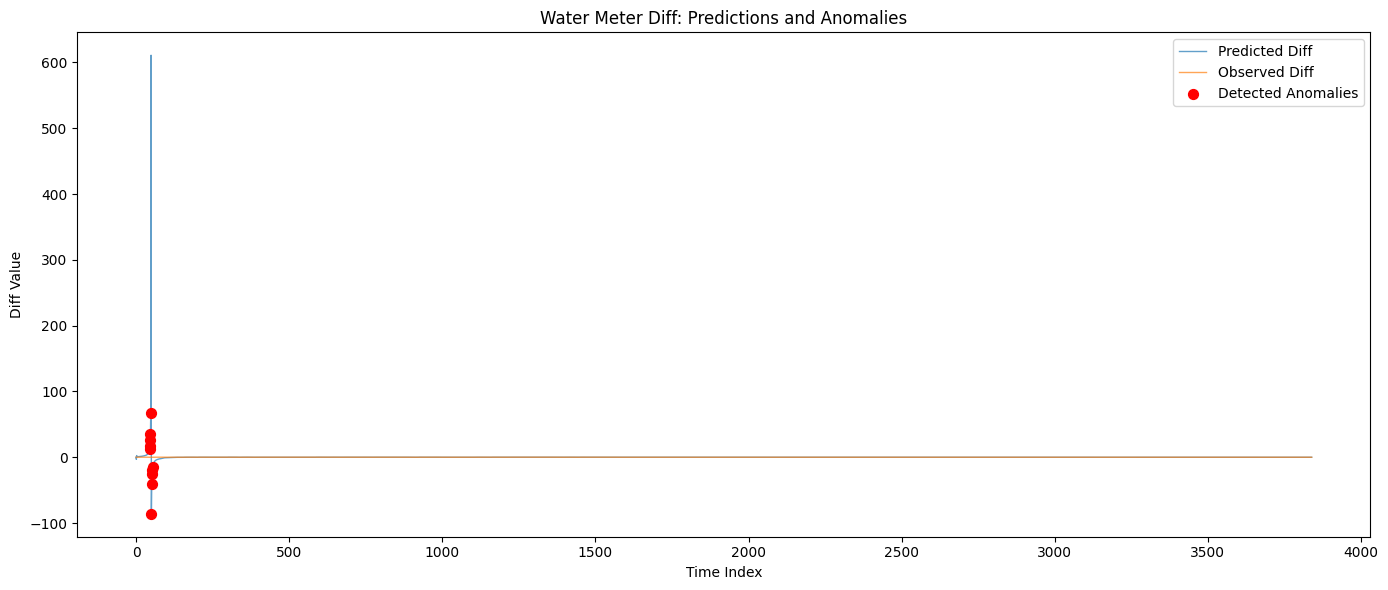

In [35]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

endog = df_filtered_artificial['Diff']

mod = sm.tsa.UnobservedComponents(
    endog,
    level='fixed intercept',
    seasonal=48,
    stochastic_seasonal=True
)
res = mod.fit()

# Extract matrices
ssm = res.model.ssm
T_matrix = ssm.transition[:, :, 0]  # State transition matrix (A)
Z_matrix = ssm.design[:, :, 0]      # Design/observation matrix (H)
Q_matrix = ssm.state_cov[:, :, 0]   # Process noise covariance
R_matrix = ssm.obs_cov[0, 0]        # Measurement noise variance

print(f"State dimension: {T_matrix.shape[0]}")
print(f"T_matrix shape: {T_matrix.shape}")
print(f"Z_matrix shape: {Z_matrix.shape}")
print(f"Q_matrix shape: {Q_matrix.shape}")

# CORRECT INITIALIZATION
n_states = T_matrix.shape[0]
x_hat = res.smoothed_state[:, 0]  # Initial state from smoothing
P = res.smoothed_state_cov[:, :, 0] if res.smoothed_state_cov.shape[2] > 0 else np.eye(n_states)

predictions = []
residuals = []
anomaly_scores = []

# Iterate through your time series
for t in range(len(endog)):
    obs_value = endog.iloc[t] if isinstance(endog, pd.Series) else endog[t]
    
    if np.isnan(obs_value):
        # Prediction only (no measurement update) if missing
        x_hat = T_matrix @ x_hat
        P = T_matrix @ P @ T_matrix.T + Q_matrix
    else:
        # Prediction step
        x_pred = T_matrix @ x_hat
        P_pred = T_matrix @ P @ T_matrix.T + Q_matrix
        
        # Innovation (prediction error) - ensure scalar
        y_pred = float(np.asarray(Z_matrix @ x_pred).flatten()[0])  # Convert to scalar
        innovation = float(obs_value - y_pred)
        S = float(np.asarray(Z_matrix @ P_pred @ Z_matrix.T + R_matrix).flatten()[0])  # Convert to scalar
        
        # Kalman gain
        K = (P_pred @ Z_matrix.T) / S
        
        # Update step
        x_hat = x_pred + K * innovation
        P = (np.eye(n_states) - K @ Z_matrix) @ P_pred
        
        # Store results (all scalars now)
        predictions.append(y_pred)
        residuals.append(innovation)
        anomaly_scores.append(innovation**2 / S)

# Convert to arrays (now all same shape)
predictions = np.array(predictions)
residuals = np.array(residuals)
anomaly_scores = np.array(anomaly_scores)

# Flag anomalies
anomaly_threshold = 3.84
anomalies = anomaly_scores > anomaly_threshold

print(f"\nDetected {anomalies.sum()} anomalies out of {len(anomaly_scores)} observations")

# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(range(len(predictions)), predictions, label='Predicted Diff', alpha=0.7, linewidth=1)
# Only plot observed non-NaN values
observed_idx = [i for i, v in enumerate(endog) if not np.isnan(v)]
observed_vals = [endog.iloc[i] if isinstance(endog, pd.Series) else endog[i] for i in observed_idx]
plt.plot(observed_idx, observed_vals, label='Observed Diff', alpha=0.7, linewidth=1)

# Plot anomalies
anomaly_idx = np.where(anomalies)[0]
if len(anomaly_idx) > 0:
    plt.scatter(anomaly_idx, predictions[anomaly_idx], 
                color='red', label='Detected Anomalies', s=50, zorder=5)

plt.legend()
plt.xlabel('Time Index')
plt.ylabel('Diff Value')
plt.title('Water Meter Diff: Predictions and Anomalies')
plt.tight_layout()
plt.show()


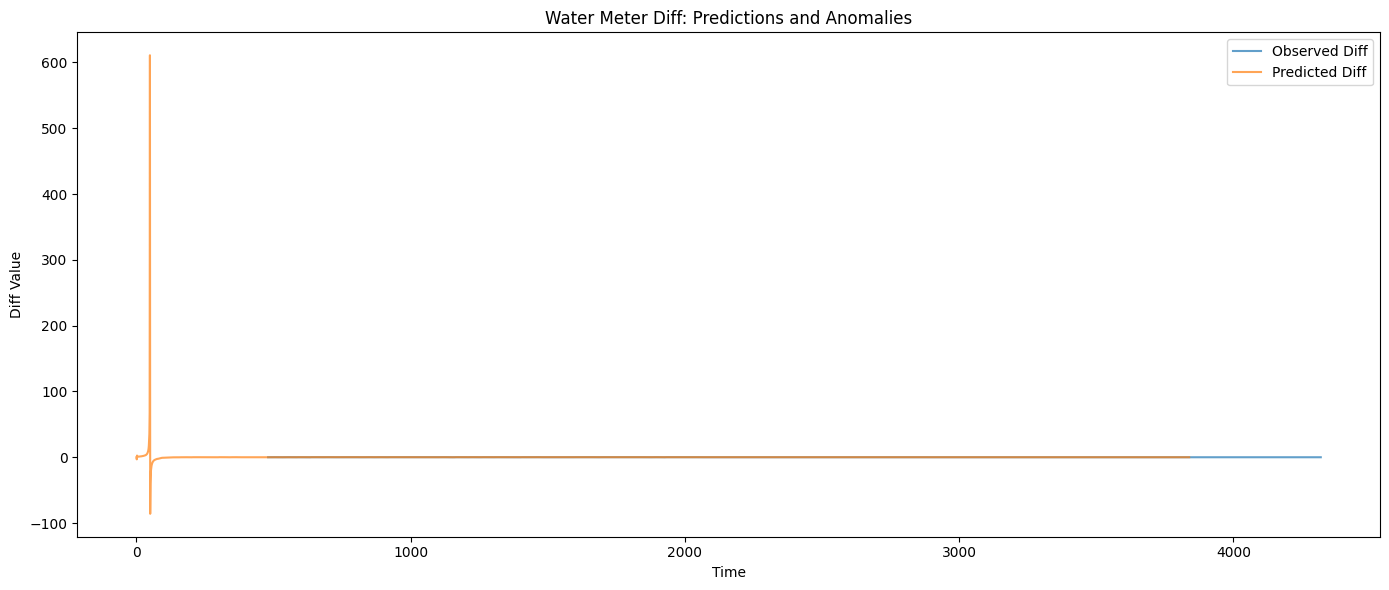

In [36]:
# Get the smoothed level and seasonal components
smoothed_states = res.smoothed_state
smoothed_level = res.level
smoothed_seasonal = res.seasonal

# Visualize predictions vs actual
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(endog, label='Observed Diff', alpha=0.7)
plt.plot(predictions, label='Predicted Diff', alpha=0.7)
#plt.scatter(np.where(anomalies)[0], endog[np.where(anomalies)[0]], 
#            color='red', label='Detected Anomalies', s=50)
plt.legend()
plt.xlabel('Time')
plt.ylabel('Diff Value')
plt.title('Water Meter Diff: Predictions and Anomalies')
plt.tight_layout()
plt.show()



Kalman Filter Performance Metrics

Data Summary:
----------------------------------------------------------------------
  n_nonzero_measurements                       : 3610
  n_total_measurements                         : 3840
  nonzero_percentage                           : 94.010417

Prediction Accuracy (All Data):
----------------------------------------------------------------------
  MAE_prediction                               : 9.878970e-03
  RMSE_prediction                              : 0.014442
  ME_prediction                                : -1.895999e-06
  MedAE_prediction                             : 7.032544e-03
  MAPE_prediction                              : 1.378282e+09
  NRMSE_prediction                             : 0.430947
  R2_prediction                                : 0.814284

Prediction Accuracy (Non-Zero Only):
----------------------------------------------------------------------
  MAE_prediction_nonzero                       : 9.023609e-03
  RMSE_predict

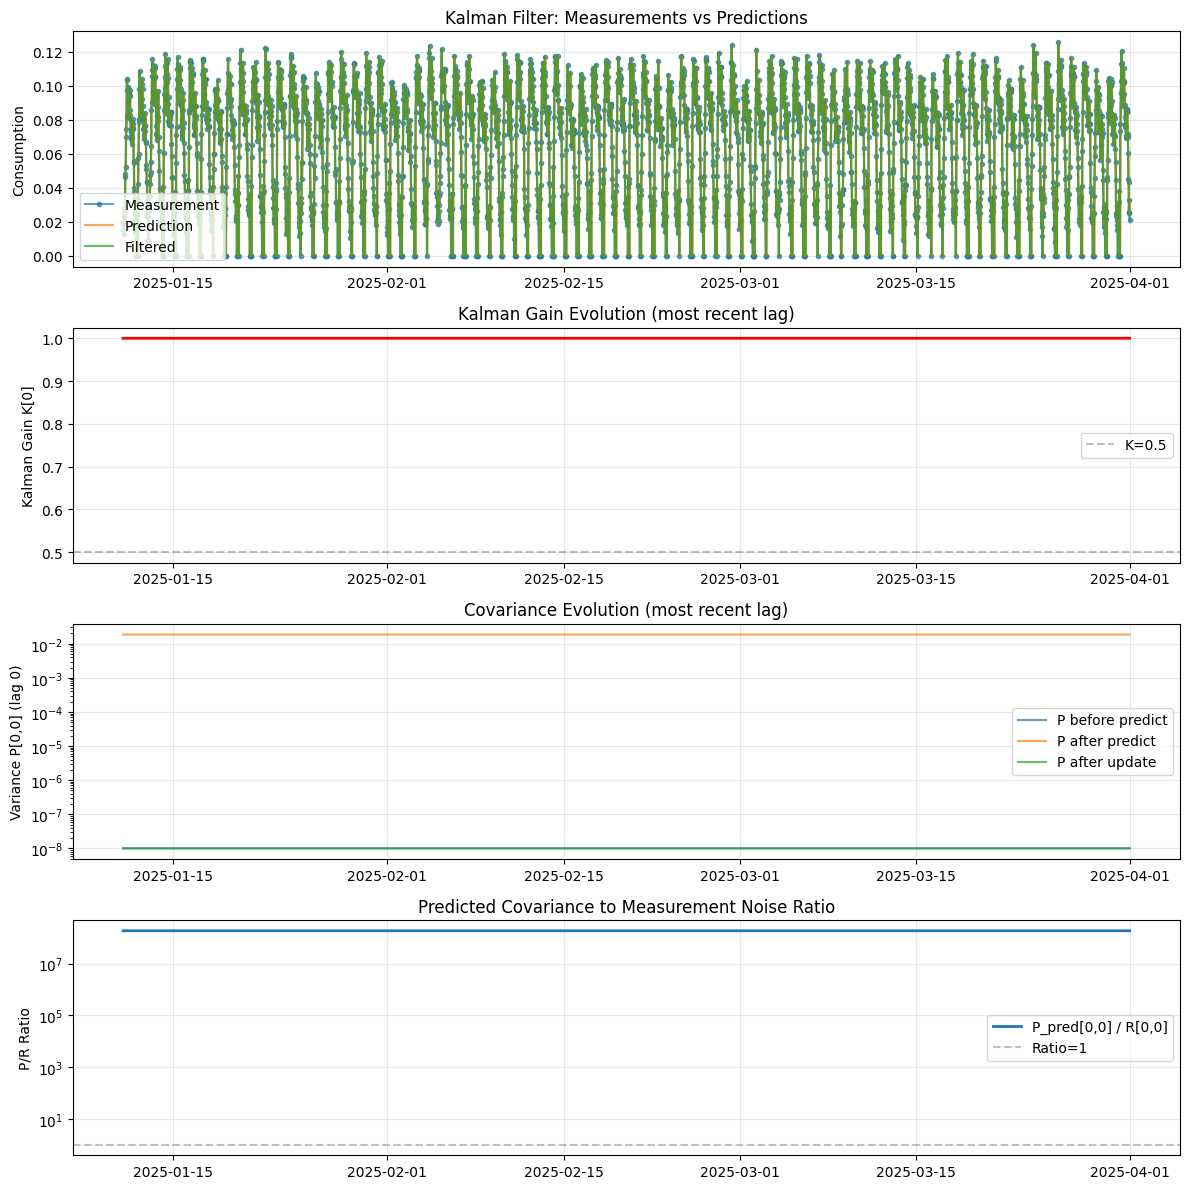


DIAGNOSTIC SUMMARY
K_lag0   - Mean: 1.0000, Min: 1.0000, Max: 1.0000
P_pred_lag0_var - Mean: 1.865911e-02, Min: 1.865911e-02, Max: 1.865911e-02
P/R Ratio - Mean: 186591119.4659, Min: 186591119.4659, Max: 186591119.4659
Q/R Ratio (constant): 8.956369e+09


In [37]:
kf_test = WaterMeterKalmanFilterSeasonalLags(A=T_matrix, Q=np.eye(48)*Q_matrix, R=np.eye(48)*R_matrix)

df_filtered_artificial = kf_test.filter_dataframe(
        df_artificial,
        anomaly_threshold=3.0,
        return_diagnostics=True
)

df_filtered_artificial = df_filtered_artificial[48*10:]

metrics = KalmanFilterMetrics.compute_all_metrics(
    df_filtered_artificial,
    nonzero_threshold=0.01
)
KalmanFilterMetrics.print_metrics_report(metrics)


fig, axes = plt.subplots(4, 1, figsize=(12, 12))

# Plot 1: Measurements vs Predictions
axes[0].plot(df_filtered_artificial['timestamp'], df_filtered_artificial['Diff'], 
             label='Measurement', alpha=0.7, marker='.')
axes[0].plot(df_filtered_artificial['timestamp'], df_filtered_artificial['consumption_pred'], 
             label='Prediction', alpha=0.7)
axes[0].plot(df_filtered_artificial['timestamp'], df_filtered_artificial['consumption_filtered'], 
             label='Filtered', alpha=0.7)
axes[0].set_ylabel('Consumption')
axes[0].set_title('Kalman Filter: Measurements vs Predictions')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Kalman Gain for Most Recent Lag
axes[1].plot(df_filtered_artificial['timestamp'], df_filtered_artificial['K_lag0'], 
             color='red', linewidth=2)
axes[1].set_ylabel('Kalman Gain K[0]')
axes[1].set_title('Kalman Gain Evolution (most recent lag)')
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='K=0.5')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Covariance Evolution (most recent lag)
axes[2].plot(df_filtered_artificial['timestamp'], df_filtered_artificial['P_before_lag0_var'], 
             label='P before predict', alpha=0.7)
axes[2].plot(df_filtered_artificial['timestamp'], df_filtered_artificial['P_pred_lag0_var'], 
             label='P after predict', alpha=0.7)
axes[2].plot(df_filtered_artificial['timestamp'], df_filtered_artificial['P_updated_lag0_var'], 
             label='P after update', alpha=0.7)
axes[2].set_ylabel('Variance P[0,0] (lag 0)')
axes[2].set_title('Covariance Evolution (most recent lag)')
axes[2].set_yscale('log')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Plot 4: Key Ratios
axes[3].plot(df_filtered_artificial['timestamp'], df_filtered_artificial['P_pred_to_R_ratio'], 
             label='P_pred[0,0] / R[0,0]', linewidth=2)
axes[3].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Ratio=1')
axes[3].set_ylabel('P/R Ratio')
axes[3].set_title('Predicted Covariance to Measurement Noise Ratio')
axes[3].set_yscale('log')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("DIAGNOSTIC SUMMARY")
print("="*70)
print(f"K_lag0   - Mean: {df_filtered_artificial['K_lag0'].mean():.4f}, "
      f"Min: {df_filtered_artificial['K_lag0'].min():.4f}, "
      f"Max: {df_filtered_artificial['K_lag0'].max():.4f}")

print(f"P_pred_lag0_var - Mean: {df_filtered_artificial['P_pred_lag0_var'].mean():.6e}, "
      f"Min: {df_filtered_artificial['P_pred_lag0_var'].min():.6e}, "
      f"Max: {df_filtered_artificial['P_pred_lag0_var'].max():.6e}")

print(f"P/R Ratio - Mean: {df_filtered_artificial['P_pred_to_R_ratio'].mean():.4f}, "
      f"Min: {df_filtered_artificial['P_pred_to_R_ratio'].min():.4f}, "
      f"Max: {df_filtered_artificial['P_pred_to_R_ratio'].max():.4f}")

print(f"Q/R Ratio (constant): {df_filtered_artificial['Q_to_R_ratio'].iloc[0]:.6e}")
print("="*70)


In [38]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13538 entries, 2880 to 16417
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   id         13538 non-null  int64         
 1   timestamp  13538 non-null  datetime64[ns]
 2   hodnota    13538 non-null  float64       
 3   Diff       13538 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 423.2 KB


In [39]:
df = df2.copy()
expected_interval_seconds = 30*60
tolerance_percent = 10
seasonal_period_hours = 24

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

# Remove rows with NaN in Diff (missing/invalid consumption data)
df_valid = df.dropna(subset=['Diff']).reset_index(drop=True)

if len(df_valid) == 0:
    raise ValueError("No valid data points after removing NaN values")

# Calculate state dimension based on seasonal period
measurements_per_period = int((seasonal_period_hours * 3600) / expected_interval_seconds)
state_dim = measurements_per_period

if len(df_valid) < state_dim + 10:
    print(
        f"Only {len(df_valid)} valid points for state dimension {state_dim}. "
        f"Consider using more data or reducing seasonal_period_hours."
    )

# Calculate total time span and expected number of readings
time_span_seconds = (df_valid['timestamp'].iloc[-1] - df_valid['timestamp'].iloc[0]).total_seconds()
expected_num_readings = int(time_span_seconds / expected_interval_seconds) + 1

# Calculate time differences between consecutive points (in seconds)
time_diffs_seconds = df_valid['timestamp'].diff().dt.total_seconds()

# Calculate tolerance bounds
expected_interval_min = expected_interval_seconds * (1 - tolerance_percent / 100.0)
expected_interval_max = expected_interval_seconds * (1 + tolerance_percent / 100.0)

# Extract diff values
diff_values = df_valid['Diff'].values

# Create state vectors with seasonal lags
# state[i] = [diff[i], diff[i-1], diff[i-2], ..., diff[i-state_dim+1]]
n_points = len(diff_values)
n_valid_states = n_points - state_dim + 1

if n_valid_states < 2:
    raise ValueError(
        f"Insufficient data for state construction. "
        f"Need at least {state_dim + 1} points, have {n_points}. "
        f"Consider reducing seasonal_period_hours or using more data."
    )

state_sequence = np.zeros((n_valid_states, state_dim))

for i in range(n_valid_states):
    # State vector: [diff(t), diff(t-1), ..., diff(t-state_dim+1)]
    state_sequence[i, :] = diff_values[i:i+state_dim]

# Construct valid state pairs
valid_state_pairs = []

for i in range(n_valid_states - 1):
    # Check if diffs in x_t vector are within range +1 diff which is a diff between last two elems in x_next
    time_diffs = time_diffs_seconds.iloc[i:i+state_dim+1]
    if not all((expected_interval_min <= time_diffs) & (time_diffs <= expected_interval_max)):
        continue
    
    x_t = state_sequence[i, :].reshape(-1, 1)      # (state_dim, 1)
    x_next = state_sequence[i+1, :].reshape(-1, 1)  # (state_dim, 1)
    valid_state_pairs.append((x_t, x_next))
        
    

# Calculate validity percentage
n_valid_pairs = len(valid_state_pairs)
expected_num_pairs = expected_num_readings - state_dim  # Adjusted for state construction

if expected_num_pairs > 0:
    validity_percentage = (n_valid_pairs / expected_num_pairs) * 100
else:
    validity_percentage = 0.0

# Warn if validity is too low
if validity_percentage < 70.0:
    print(
        f"Data quality warning: Only {validity_percentage:.1f}% of expected pairs are valid.\n"
        f"  Expected pairs (based on time span): {expected_num_pairs}\n"
        f"  Valid pairs found: {n_valid_pairs}\n"
        f"  Missing/invalid: {expected_num_pairs - n_valid_pairs}\n"
        f"  This may indicate significant NaN values, gaps, or irregular sampling."
    )

if len(valid_state_pairs) < 2:
    raise ValueError(
        f"Only {len(valid_state_pairs)} valid consecutive pairs found "
        f"within tolerance {tolerance_percent}% of {expected_interval_seconds} seconds. "
        f"Consider relaxing tolerance or checking data quality."
    )



Data quality warning: Only 25.3% of expected pairs are valid.
  Expected pairs (based on time span): 13814
  Valid pairs found: 3501
  Missing/invalid: 10313
  This may indicate significant NaN values, gaps, or irregular sampling.


In [44]:
from kf_wrls_seasonal_lags import KalmanFilterWRLSEstimatorSeasonalLags
from kf_seasonal_lags import WaterMeterKalmanFilterSeasonalLags

estimator = KalmanFilterWRLSEstimatorSeasonalLags(lambda_forget=0.9999)
#df_artificial = pd.read_csv('./data/artificial_water_consumption_3months.csv')

A, Q, R, metadata = estimator.estimate_from_dataframe(
    df2,
    expected_interval_seconds=30*60,
    tolerance_percent=10.0,
    verbose=True
)
print(R)

kf2 = WaterMeterKalmanFilterSeasonalLags(A, Q, R)

c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\test\kf_wrls_seasonal_lags.py:215: UserWarning: Data quality warning: Only 25.3% of expected pairs are valid.
  Expected pairs (based on time span): 13814
  Valid pairs found: 3501
  Missing/invalid: 10313
  This may indicate significant NaN values, gaps, or irregular sampling.
  warnings.warn(
c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\test\kf_wrls_seasonal_lags.py:410: UserWarning: Potentially unstable A detected at update 100. Max eigenvalue: 1.0168
  warnings.warn(f"Potentially unstable A detected at update {idx + 1}. Max eigenvalue: {max_eig:.4f}")


✓ Data Processing Summary:
  Time span: 6930.9 hours
  Expected readings (based on 1800s interval): 13862
  Seasonal period: 24.0 hours
  State dimension (measurements per period): 48
  Expected pairs: 13814
  Valid pairs found: 3501
  Data validity: 25.3%


Starting WRLS estimation...
  State dimension: 48
  Forgetting factor λ = 0.9999

  Processed 100/3501 updates... Max |eigval(A)| = 1.0168
  Processed 200/3501 updates... Max |eigval(A)| = 0.9977
  Processed 300/3501 updates... Max |eigval(A)| = 0.9925
  Processed 400/3501 updates... Max |eigval(A)| = 0.9938
  Processed 500/3501 updates... Max |eigval(A)| = 0.9937
  Processed 600/3501 updates... Max |eigval(A)| = 0.9954
  Processed 700/3501 updates... Max |eigval(A)| = 0.9955
  Processed 800/3501 updates... Max |eigval(A)| = 0.9961
  Processed 900/3501 updates... Max |eigval(A)| = 0.9956
  Processed 1000/3501 updates... Max |eigval(A)| = 0.9957
  Processed 1100/3501 updates... Max |eigval(A)| = 0.9963
  Processed 1200/3501 updates.


Kalman Filter Performance Metrics

Data Summary:
----------------------------------------------------------------------
  n_nonzero_measurements                       : 3046
  n_total_measurements                         : 13058
  nonzero_percentage                           : 23.326696
  n_anomalies_detected                         : 264

Prediction Accuracy (All Data):
----------------------------------------------------------------------
  MAE_prediction                               : 7.162339e-03
  RMSE_prediction                              : 0.017410
  ME_prediction                                : 6.253380e-04
  MedAE_prediction                             : 2.580211e-03
  MAPE_prediction                              : 2.208455e+09
  NRMSE_prediction                             : 0.797981
  R2_prediction                                : 0.363226

Prediction Accuracy (Non-Zero Only):
----------------------------------------------------------------------
  MAE_prediction_nonzer

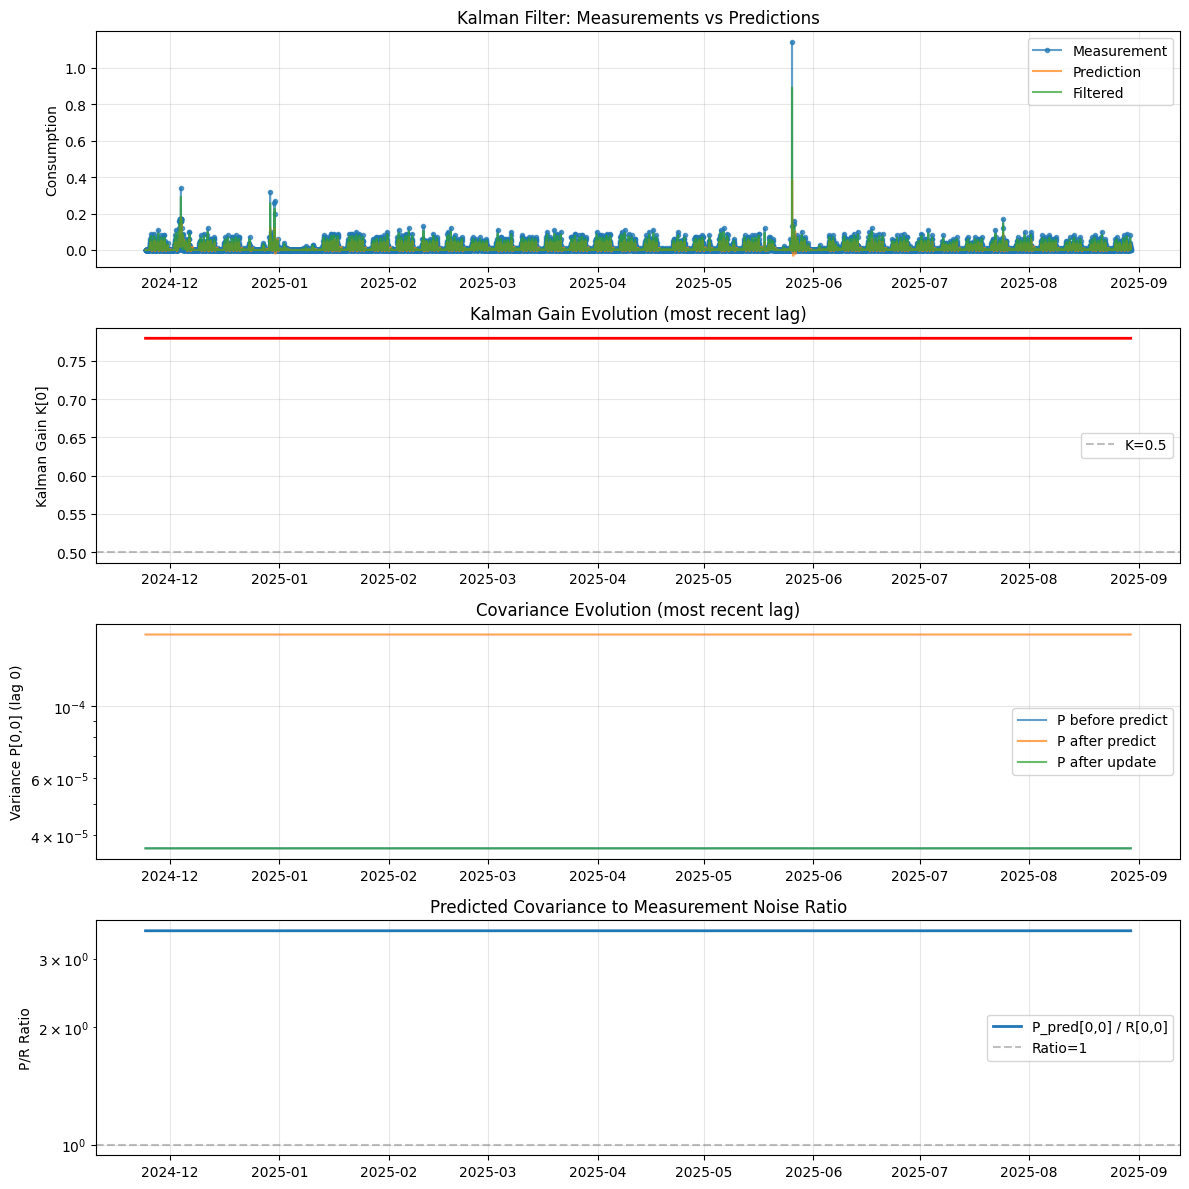


DIAGNOSTIC SUMMARY
K_lag0   - Mean: 0.7795, Min: 0.7795, Max: 0.7795
P_pred_lag0_var - Mean: 1.656105e-04, Min: 1.656105e-04, Max: 1.656105e-04
P/R Ratio - Mean: 3.5346, Min: 3.5346, Max: 3.5346
Q/R Ratio (constant): 8.351082e-02


In [41]:
df2_filtered = kf2.filter_dataframe(
        df2,
        anomaly_threshold=3.0,
        return_diagnostics=True
)

df2_filtered = df2_filtered[48*10:]

metrics = KalmanFilterMetrics.compute_all_metrics(
    df2_filtered,
    nonzero_threshold=0.01
)
KalmanFilterMetrics.print_metrics_report(metrics)


fig, axes = plt.subplots(4, 1, figsize=(12, 12))

# Plot 1: Measurements vs Predictions
axes[0].plot(df2_filtered['timestamp'], df2_filtered['Diff'], 
             label='Measurement', alpha=0.7, marker='.')
axes[0].plot(df2_filtered['timestamp'], df2_filtered['consumption_pred'], 
             label='Prediction', alpha=0.7)
axes[0].plot(df2_filtered['timestamp'], df2_filtered['consumption_filtered'], 
             label='Filtered', alpha=0.7)
axes[0].set_ylabel('Consumption')
axes[0].set_title('Kalman Filter: Measurements vs Predictions')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Kalman Gain for Most Recent Lag
axes[1].plot(df2_filtered['timestamp'], df2_filtered['K_lag0'], 
             color='red', linewidth=2)
axes[1].set_ylabel('Kalman Gain K[0]')
axes[1].set_title('Kalman Gain Evolution (most recent lag)')
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='K=0.5')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Covariance Evolution (most recent lag)
axes[2].plot(df2_filtered['timestamp'], df2_filtered['P_before_lag0_var'], 
             label='P before predict', alpha=0.7)
axes[2].plot(df2_filtered['timestamp'], df2_filtered['P_pred_lag0_var'], 
             label='P after predict', alpha=0.7)
axes[2].plot(df2_filtered['timestamp'], df2_filtered['P_updated_lag0_var'], 
             label='P after update', alpha=0.7)
axes[2].set_ylabel('Variance P[0,0] (lag 0)')
axes[2].set_title('Covariance Evolution (most recent lag)')
axes[2].set_yscale('log')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Plot 4: Key Ratios
axes[3].plot(df2_filtered['timestamp'], df2_filtered['P_pred_to_R_ratio'], 
             label='P_pred[0,0] / R[0,0]', linewidth=2)
axes[3].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Ratio=1')
axes[3].set_ylabel('P/R Ratio')
axes[3].set_title('Predicted Covariance to Measurement Noise Ratio')
axes[3].set_yscale('log')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("DIAGNOSTIC SUMMARY")
print("="*70)
print(f"K_lag0   - Mean: {df2_filtered['K_lag0'].mean():.4f}, "
      f"Min: {df2_filtered['K_lag0'].min():.4f}, "
      f"Max: {df2_filtered['K_lag0'].max():.4f}")

print(f"P_pred_lag0_var - Mean: {df2_filtered['P_pred_lag0_var'].mean():.6e}, "
      f"Min: {df2_filtered['P_pred_lag0_var'].min():.6e}, "
      f"Max: {df2_filtered['P_pred_lag0_var'].max():.6e}")

print(f"P/R Ratio - Mean: {df2_filtered['P_pred_to_R_ratio'].mean():.4f}, "
      f"Min: {df2_filtered['P_pred_to_R_ratio'].min():.4f}, "
      f"Max: {df2_filtered['P_pred_to_R_ratio'].max():.4f}")

print(f"Q/R Ratio (constant): {df2_filtered['Q_to_R_ratio'].iloc[0]:.6e}")
print("="*70)


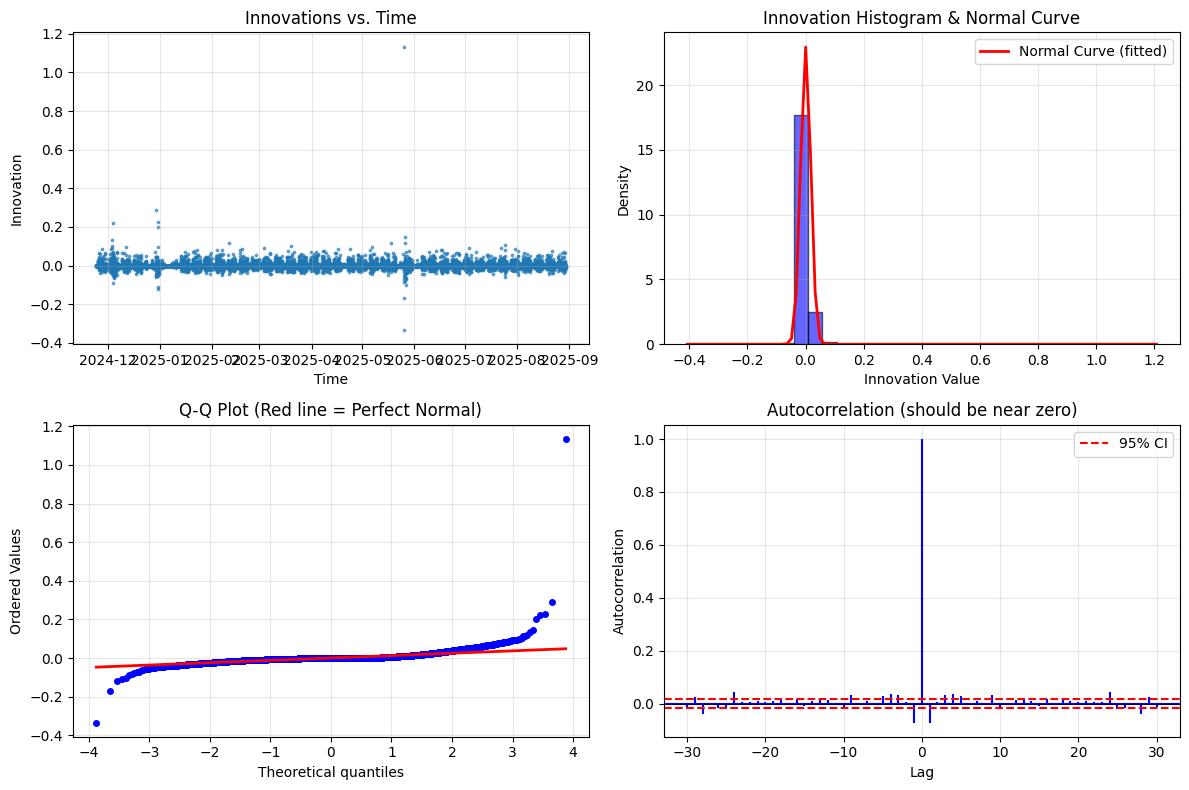

In [42]:
innovations_artificial = df2_filtered['innovation'].values

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Time-series scatter (your existing plot)
axes[0, 0].scatter(df2_filtered['timestamp'], innovations_artificial, s=3, alpha=0.6)
axes[0, 0].set_title('Innovations vs. Time')
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Innovation')
axes[0, 0].grid(True, alpha=0.3)

# 2. Histogram with normal curve overlay
axes[0, 1].hist(innovations_artificial, bins=30, density=True, alpha=0.6, color='blue', edgecolor='black')
xmin, xmax = axes[0, 1].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, np.mean(innovations_artificial), np.std(innovations_artificial))
axes[0, 1].plot(x, p, 'r', linewidth=2, label='Normal Curve (fitted)')
axes[0, 1].set_title('Innovation Histogram & Normal Curve')
axes[0, 1].set_xlabel('Innovation Value')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q Plot with reference line
stats.probplot(innovations_artificial, dist="norm", plot=axes[1, 0])
axes[1, 0].get_lines()[0].set_markerfacecolor('blue')
axes[1, 0].get_lines()[0].set_markeredgecolor('blue')
axes[1, 0].get_lines()[0].set_markersize(4)
axes[1, 0].get_lines()[1].set_color('red')  # Reference line (what normal should look like)
axes[1, 0].get_lines()[1].set_linewidth(2)
axes[1, 0].set_title('Q-Q Plot (Red line = Perfect Normal)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Autocorrelation plot
axes[1, 1].acorr(innovations_artificial - np.mean(innovations_artificial), maxlags=30, usevlines=True, color='blue')
axes[1, 1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[1, 1].axhline(y=1.96/np.sqrt(len(innovations_artificial)), color='r', linestyle='--', label='95% CI')
axes[1, 1].axhline(y=-1.96/np.sqrt(len(innovations_artificial)), color='r', linestyle='--')
axes[1, 1].set_title('Autocorrelation (should be near zero)')
axes[1, 1].set_xlabel('Lag')
axes[1, 1].set_ylabel('Autocorrelation')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Filtered to date range: ('2025-03-10', '2025-03-11')
Plotting 48 points across 3 columns


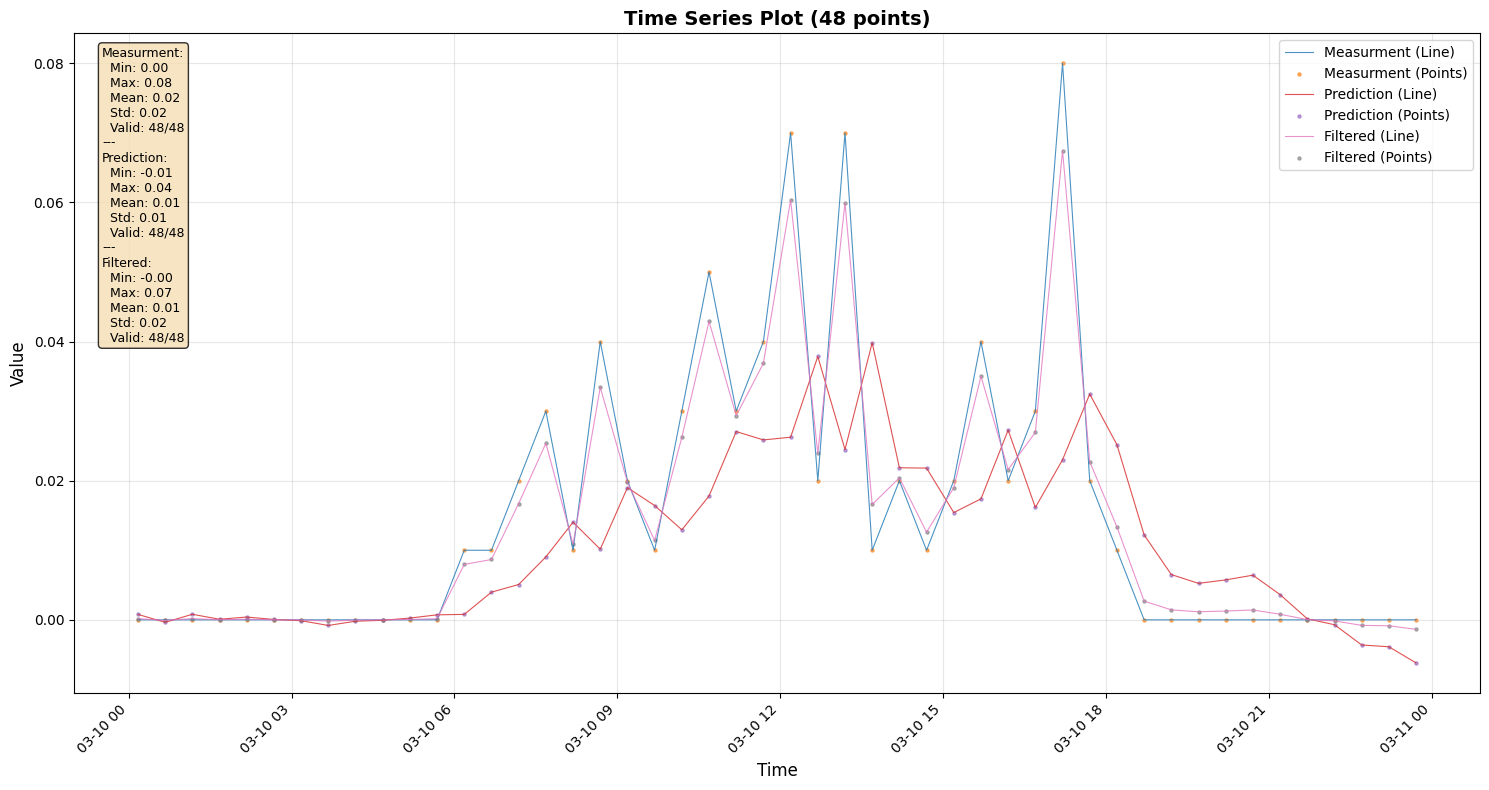

In [43]:
plot_timeseries(df2_filtered, ['Diff', 'consumption_pred', 'consumption_filtered'], date_range=("2025-03-10", "2025-03-11"), plot_type="both", labels=['Measurment', 'Prediction', 'Filtered'])